# Chip Timing Markers & TTP Timeline Analysis

For each experiment under the `*_nc_subtract` dataset tree, builds one combined view of:

1. `idx_start`, `idx_settled`, `idx_end`, `idx_active` — read directly off the `Well`
   objects returned by `chip_v6_utils.load_and_preprocess_v6` (the titan_v6 raw-chip
   conversion `01_curve_preprocessing_v6.py` uses).
2. The timestamp corresponding to each of those indices (Section 3 explains why that's
   `well.time_npr[idx]`, not `well.time[idx]`).
3. `max_significant_index` — the NC-subtract truncation point, computed exactly the way
   `01_curve_preprocessing_v6.py --nc_subtract` computes it — plus its timestamp.
4. TTP (Time-To-Positive), computed from the already-processed `curve_for_training.joblib`,
   the same way the existing kinetic-feature notebook (`new_chip_analysis.ipynb`) does it.

Section 6 puts all five markers on one shared, zero-referenced timeline, in the order
`idx_start -> idx_settled -> max_significant_index (if any) -> TTP -> idx_end`.


In [1]:
%matplotlib inline
import os
import sys
import importlib
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

try:
    _nb = globals().get('__vsc_ipynb_file__')
    notebook_dir = os.path.dirname(os.path.dirname(_nb)) if _nb else os.getcwd()
    os.chdir(notebook_dir)
except Exception:
    pass

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
sys.path.insert(0, os.path.join(os.getcwd(), 'utils'))
sys.path.insert(0, os.path.join(os.getcwd(), 'utils', '01_curve_preprocessing'))

%load_ext autoreload
%autoreload 2

import config
import sigmoid_fitting as sp
from chip_v6_utils import load_and_preprocess_v6

# Reused (not copied) so Section 4's max_significant_index logic stays byte-for-byte
# identical to what 01_curve_preprocessing_v6.py --nc_subtract actually runs.
prep01 = importlib.import_module("01_curve_preprocessing_v6")

print("Working directory:", os.getcwd())



[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0

Working directory: /vol/bitbucket/gk225/POC_DDM/gk_code/main


## 1. Choose experiments to analyze

`config.get_label_mappings` distinguishes nc_subtract-treated data by checking
`Path(exp_path).parent.name.endswith("nc_subtract")` — i.e. the dataset *tree* you load
from, not a suffix on each experiment folder's own name (the per-experiment folders
under `POC_DDM_multi_nc_subtract` are named identically to their `POC_DDM_multi`
counterparts).

The two trees are **not interchangeable**, though (verified directly by listing both):
`POC_DDM_multi_nc_subtract` holds only *derived* outputs (`curve_for_training.joblib`,
model results, visualizations) — no raw `.bin` captures at all. `load_and_preprocess_v6`
(Sections 2-4, raw `Well` objects) needs the raw tree, `POC_DDM_multi`; Section 5's TTP
needs the nc_subtract tree's `curve_for_training.joblib` specifically, since that's the
one actually written with `--nc_subtract` truncation applied. Both trees share identical
experiment folder names, so one experiment-name list drives both.

Loading raw Wells via `load_and_preprocess_v6` is the slow step (~10-20s per
experiment), so `N_EXPERIMENTS` keeps Sections 2-4 & 6 to a handful — widen the slice to
cover more. Section 5 (TTP) is cheap (joblib-based) and runs over every experiment
regardless.


In [2]:
RAW_ROOT = Path(config.FINAL_EXP_FOLDER)            # has the raw .bin captures
NC_SUBTRACT_ROOT = Path(config.FINAL_EXP_FOLDER + "_nc_subtract")  # derived-only; nc_subtract-truncated joblibs
# NC_SUBTRACT_ROOT = Path(config.MULTI_EXP_FOLDER)  # derived-only; nc_subtract-truncated joblibs
assert RAW_ROOT.exists(), f"Not found: {RAW_ROOT}"
assert NC_SUBTRACT_ROOT.exists(), f"Not found: {NC_SUBTRACT_ROOT}"

all_exp_names = sorted([
    name for name in os.listdir(NC_SUBTRACT_ROOT)
    if (NC_SUBTRACT_ROOT / name).is_dir() and name not in config.EXCLUDED_FOLDERS
])

# Drop known one-off test runs. (The pasted snippet this notebook is based on tried to do
# this via Experiment.str.endswith('test_05_nc_subtract')/'nc_subtract' -- that never
# matches current folder names, since the suffix lives on the parent tree, not here.)
EXCLUDE_SUBSTRINGS = ["test_05", "Elena", "U_norm_", "U_lambda"]
exp_names = [n for n in all_exp_names if not any(s in n for s in EXCLUDE_SUBSTRINGS)]

print(f"[*] Found {len(exp_names)} candidate experiment folder(s):")
for n in exp_names:
    print("   -", n)

N_EXPERIMENTS = 2  # raise this to cover more -- each one costs ~10-20s to load raw Wells
exp_names_subset = exp_names[-3:]
exp_paths_subset = [RAW_ROOT / n for n in exp_names_subset]  # raw tree, for load_and_preprocess_v6

print(f"\n[*] Using {len(exp_names_subset)} experiment(s) for Sections 2-4 & 6:", exp_names_subset)
print(f"[*] All {len(exp_names)} experiment(s) (excluding test runs) will be used for Section 5 (TTP).")


[*] Found 8 candidate experiment folder(s):
   - D20260731_E00_C00_F4500KHz_U_DDM_01_01
   - D20260731_E00_C00_F4500KHz_U_DDM_01_04
   - D20260804_E00_C00_F4500KHz_U_DDM_02_01
   - D20260804_E00_C00_F4500KHz_U_DDM_02_03
   - D20260804_E00_C00_F4500KHz_U_DDM_02_04
   - D20260806_E00_C00_F4500KHz_U_DDM_01_06
   - D20260807_E00_C00_F4500KHz_U_DDM_02_07
   - D20260808_E00_C00_F4500KHz_U_DDM_03_01

[*] Using 3 experiment(s) for Sections 2-4 & 6: ['D20260806_E00_C00_F4500KHz_U_DDM_01_06', 'D20260807_E00_C00_F4500KHz_U_DDM_02_07', 'D20260808_E00_C00_F4500KHz_U_DDM_03_01']
[*] All 8 experiment(s) (excluding test runs) will be used for Section 5 (TTP).


## 2. Raw Wells via `load_and_preprocess_v6`: `idx_start`, `idx_settled`, `idx_end`, `idx_active`

`01_curve_preprocessing_v6.py` itself treats `well0 = all_exp_data[0].wells_list[0]` as
representative for an experiment's timing markers (see `save_experiment_data_restructured`,
where these get written into the `"idxs"` key of `curve_for_training.joblib`) — they come
from acquisition hardware/firmware timing, not from any individual well's signal, so
they're shared across all wells/vref-groups in the same experiment.


In [3]:
exp_names_subset

['D20260806_E00_C00_F4500KHz_U_DDM_01_06',
 'D20260807_E00_C00_F4500KHz_U_DDM_02_07',
 'D20260808_E00_C00_F4500KHz_U_DDM_03_01']

In [4]:
FORCE_RELOAD = False  # set True to reprocess even if cache exists
CACHE_DIR = Path("/vol/bitbucket/gk225/POC_DDM/gk_code/main/notebooks/_cache_timing_markers")
CACHE_DIR.mkdir(exist_ok=True)

markers_records = []
loaded_exp_data = {}  # cache so Sections 3/4/6 don't reload raw data

for exp_path in exp_paths_subset:
    exp_name = exp_path.name
    cache_file = CACHE_DIR / f"{exp_name}.joblib"

    if not FORCE_RELOAD and cache_file.exists():
        print(f"[cache] Loading {exp_name} from cache ...")
        _cached = joblib.load(cache_file)
        loaded_exp_data[exp_name] = _cached["all_exp_data"]
        markers_records.append(_cached["markers_record"])
        continue

    print(f"[*] Loading raw Wells for: {exp_name} ...")
    try:
        all_exp_data = load_and_preprocess_v6(
            exp_path=exp_path, n_wells=config.N_WELLS, n_a_type=config.N_A_TYPE, vref_ref_idx="all",
        )
        well0 = all_exp_data[0].wells_list[0]
    except Exception as e:
        print(f"    [!] Skipping {exp_name} -- failed to load raw Wells ({e!r}). "
              f"Likely a CV/summary folder without raw binaries rather than a real experiment.")
        continue

    _mapping = config.LABEL_MAPPINGS.get(exp_name, {})
    rec = {
        "Experiment": exp_name,
        # "Label": sorted(set(_mapping.values())) if _mapping else [],
        "idx_start": int(well0.idx_start),
        "idx_settled": int(well0.idx_settled),
        "idx_end": int(well0.idx_end),
        "n_active_pixels": int(np.sum(well0.idx_active)),
        "n_total_pixels": int(len(well0.idx_active)),
        "time_npr_len": len(well0.time_npr),
    }
    loaded_exp_data[exp_name] = all_exp_data
    markers_records.append(rec)

    joblib.dump({"all_exp_data": all_exp_data, "markers_record": rec}, cache_file, compress=3)
    print(f"    [cache] Saved -> {cache_file.name}")

markers_df = pd.DataFrame(markers_records)
exp_names_subset = list(loaded_exp_data.keys())  # keep only experiments that actually loaded
markers_df

[cache] Loading D20260806_E00_C00_F4500KHz_U_DDM_01_06 from cache ...
[cache] Loading D20260807_E00_C00_F4500KHz_U_DDM_02_07 from cache ...
[*] Loading raw Wells for: D20260808_E00_C00_F4500KHz_U_DDM_03_01 ...
[INFO] D20260808_E00_C00_F4500KHz_U_DDM_03_01: found 1 readout file(s). Processing...
Loaded vref sweep from 20260808T162013.42_vref_sweep.bin: n_vrefs=2
[INFO] Slice 1/2: DDM_03_01__vref_idx=0_vref=3410
EXP PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/D20260808_E00_C00_F4500KHz_U_DDM_03_01 
VREF PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/D20260808_E00_C00_F4500KHz_U_DDM_03_01/20260808T162013.42_vref_sweep.bin 
Load vref... 
Loaded vref list: n_vrefs=2, first=3410, last=3510
EXP PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/D20260808_E00_C00_F4500KHz_U_DDM_03_01 
READOUT PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/D20260808_E00_C00_F4500KHz_U_DDM_03_01/20260808T162124.38_readout_time.bin 
Load data... 
(290, 204, 2, 437)
Time vect

,Experiment,idx_start,idx_settled,idx_end,n_active_pixels,n_total_pixels,time_npr_len
0,D20260806_E00_C00_F4500KHz_U_DDM_01_06,22,24,867,1970,5916,868
1,D20260807_E00_C00_F4500KHz_U_DDM_02_07,29,31,873,1047,5916,874
2,D20260808_E00_C00_F4500KHz_U_DDM_03_01,14,19,436,0,5916,437


## 3. Corresponding timestamp for each idx

`idx_start`/`idx_settled`/`idx_end` are indices into `well.time_npr` (the raw,
full-length per-frame clock) — **not** `well.time`. `well.time` is itself a derived
property (`titan_v6/Well.py`):

```python
@property
def time(self):
    return self.time_npr[self.idx_settled:self.idx_end] - self.time_npr[self.idx_start]
```

so it is already sliced to `[idx_settled:idx_end]` and zeroed to `idx_start`'s
timestamp — indexing it with `idx_end` itself is out of bounds (verified directly: for
one real experiment, `idx_end=884` but `len(well.time)=862`). `time_npr[idx]` is
therefore the correct lookup for these three markers. `idx_active` indexes pixels, not
time, so it has no associated timestamp.


In [5]:
def add_idx_timestamps(markers_df, loaded_exp_data):
    out = markers_df.copy()
    for col in ["idx_start", "idx_settled", "idx_end"]:
        out[f"t_{col}"] = out.apply(
            lambda row: loaded_exp_data[row["Experiment"]][0].wells_list[0].time_npr[row[col]],
            axis=1,
        )
    return out

markers_df = add_idx_timestamps(markers_df, loaded_exp_data)
markers_df[["Experiment", "idx_start", "t_idx_start", "idx_settled", "t_idx_settled", "idx_end", "t_idx_end"]]

,Experiment,idx_start,t_idx_start,idx_settled,t_idx_settled,idx_end,t_idx_end
0,D20260806_E00_C00_F4500KHz_U_DDM_01_06,22,61.0,24,67.0,867,2468.0
1,D20260807_E00_C00_F4500KHz_U_DDM_02_07,29,81.0,31,87.0,873,2489.0
2,D20260808_E00_C00_F4500KHz_U_DDM_03_01,14,79.0,19,107.0,436,2485.0


## 4. `max_significant_index` (NC-subtract truncation logic) + its timestamp

Exactly replicates the truncation-index calculation `01_curve_preprocessing_v6.py
--nc_subtract` runs: per-curve derivative-minimum index, voted across all curves in the
experiment, kept only if it recurs in more than 1/3 of them. `None` means no such
common transient was found (truncation is skipped for that experiment).

The raw value `max_significant_index` is itself an index into `well.time` (`reconstruct_data`
builds `X_time` from `well0.time`), which is `time_npr[idx_settled:idx_end] -
time_npr[idx_start]` — so position `k` there is raw `time_npr` index `idx_settled + k`.
To put it on the same `idx_*` axis as Sections 2-3 (all `time_npr`-indexed):

```
max_significant_index_norm = max_significant_index + idx_settled
t_max_significant_index     = time_npr[max_significant_index_norm]
```


In [6]:
def compute_max_significant_index(all_exp_data, pc_only=False, exp_name=None):
    """Mirrors 01_curve_preprocessing_v6.py's --nc_subtract truncation-index logic exactly.

    pc_only: if True and 'PC' wells exist, restrict the derivative vote to PC curves only,
             then return the index to be applied to all. Falls back to all wells if no PC found.
    exp_name: required when pc_only=True — used to look up config.LABEL_MAPPINGS for PC detection.
    """
    X_time, Y_well, X_2d_bs_active = prep01.reconstruct_data(all_exp_data, attr_str="well_2d_bs_active")

    curves_for_index = X_2d_bs_active
    if pc_only:
        mapping = config.LABEL_MAPPINGS.get(exp_name, {}) if exp_name else {}
        y_label = np.array([mapping.get(int(w), str(w)) for w in Y_well])
        pc_mask = (y_label == 'PC')
        if np.any(pc_mask):
            curves_for_index = X_2d_bs_active[pc_mask]
            print(f"      [pc_only] Using {pc_mask.sum()} PC wells to determine truncation index.")
        else:
            print("      [pc_only] No 'PC' label found in LABEL_MAPPINGS — falling back to all wells.")

    ori_curve_dydx = np.array(prep01.get_derivatives(curves_for_index, X_time))
    min_indices = np.argmin(ori_curve_dydx, axis=1)

    unique_indices, counts = np.unique(min_indices, return_counts=True)
    threshold = len(curves_for_index) / 3
    significant_indices = unique_indices[counts > threshold]

    max_significant_index = int(np.max(significant_indices)) if len(significant_indices) > 0 else None
    return max_significant_index

msi_records = []
for exp_name, all_exp_data in loaded_exp_data.items():
    print(f"[*] Computing max_significant_index for: {exp_name} ...")
    msi = compute_max_significant_index(all_exp_data, pc_only=True, exp_name=exp_name)
    time_npr = loaded_exp_data[exp_name][0].wells_list[0].time_npr
    idx_settled = int(markers_df.loc[markers_df["Experiment"] == exp_name, "idx_settled"].iloc[0])

    if msi is not None:
        msi_norm = msi + idx_settled
        t_msi = float(time_npr[msi_norm])
    else:
        msi_norm, t_msi = None, np.nan

    msi_records.append({
        "Experiment": exp_name,
        "max_significant_index": msi,
        "max_significant_index_norm": msi_norm,
        "t_max_significant_index": t_msi,
    })
    print(f"    -> max_significant_index = {msi}, _norm = {msi_norm}"
          + (f" (t = {t_msi:.2f})" if msi is not None else " (none found)"))

msi_df = pd.DataFrame(msi_records)
markers_df = markers_df.merge(msi_df, on="Experiment", how="left")
markers_df

[*] Computing max_significant_index for: D20260806_E00_C00_F4500KHz_U_DDM_01_06 ...
      [pc_only] Using 791 PC wells to determine truncation index.
    -> max_significant_index = 4, _norm = 28 (t = 78.00)
[*] Computing max_significant_index for: D20260807_E00_C00_F4500KHz_U_DDM_02_07 ...
      [pc_only] Using 1814 PC wells to determine truncation index.
    -> max_significant_index = 4, _norm = 35 (t = 98.00)
[*] Computing max_significant_index for: D20260808_E00_C00_F4500KHz_U_DDM_03_01 ...
      [pc_only] Using 1755 PC wells to determine truncation index.
    -> max_significant_index = 3, _norm = 22 (t = 124.00)


,Experiment,idx_start,idx_settled,idx_end,n_active_pixels,n_total_pixels,time_npr_len,t_idx_start,t_idx_settled,t_idx_end,max_significant_index,max_significant_index_norm,t_max_significant_index
0,D20260806_E00_C00_F4500KHz_U_DDM_01_06,22,24,867,1970,5916,868,61.0,67.0,2468.0,4,28,78.0
1,D20260807_E00_C00_F4500KHz_U_DDM_02_07,29,31,873,1047,5916,874,81.0,87.0,2489.0,4,35,98.0
2,D20260808_E00_C00_F4500KHz_U_DDM_03_01,14,19,436,0,5916,437,79.0,107.0,2485.0,3,22,124.0


In [7]:
msi_df

,Experiment,max_significant_index,max_significant_index_norm,t_max_significant_index
0,D20260806_E00_C00_F4500KHz_U_DDM_01_06,4,28,78.0
1,D20260807_E00_C00_F4500KHz_U_DDM_02_07,4,35,98.0
2,D20260808_E00_C00_F4500KHz_U_DDM_03_01,3,22,124.0


In [8]:
# markers_df["Label"] = "RealTarget"
# markers_df_2 = markers_df.copy()
# markers_df_2["Label"] = "RealTarget-2"
# markers_df = pd.concat([markers_df, markers_df_2], ignore_index=True, sort=False)


In [9]:
# markers_df

## 5. TTP (Time-To-Positive) from the processed pipeline

Reuses the pixel/well-level kinetic-feature extraction already built and validated in
`new_chip_analysis.ipynb` (copied here so this notebook is self-contained), run on every
experiment in the nc_subtract tree — this works off the already-saved
`curve_for_training.joblib`, no raw reload needed, so it's cheap regardless of
`N_EXPERIMENTS` above.

Note: the original snippet this is based on filtered plots to `target_label='Target'`,
but `'Target'` is only one experiment group's label convention (others use `'S'/'C'` or
`'Conc-01'/'Conc-02'`, see `config.LABEL_MAPPINGS`) — so below this is generalized to
"all labels" / "non-NC labels" instead of a hardcoded string.


In [10]:
def process_all_curves_pixel_level(exp_folders):
    pixel_records = []
    mean_curve_records = []

    for exp_path in exp_folders:
        exp_path = Path(exp_path)
        exp_name = exp_path.name

        data_path = exp_path / config.TRAINING_DATA_PATH
        if not data_path.exists():
            continue

        print(f"Processing: {exp_name} ...")
        data = joblib.load(data_path)

        ori_curves = data["dataset"][0]
        df_std = data["kinetic_features"][0].copy()
        y_well = np.array(data["Y_well"])
        exp_timestamps = data["timestamps"]

        if hasattr(config, "LABEL_MAPPINGS") and exp_name in config.LABEL_MAPPINGS:
            mapping = config.LABEL_MAPPINGS[exp_name]
            y_label = np.array([mapping.get(w, w) for w in y_well])
        else:
            y_label = np.array(y_well)

        unique_wells = np.unique(y_well)

        df_std['Experiment'] = exp_name
        df_std['Well_ID'] = y_well
        df_std['Label'] = y_label
        df_std = df_std.loc[:, ~df_std.columns.duplicated()]
        pixel_records.append(df_std)

        for well_id in unique_wells:
            mask = (y_well == well_id)
            label = y_label[mask][0]
            mean_std = np.mean(ori_curves[mask], axis=0)
            mean_curve_records.append({
                'Experiment': exp_name,
                'Well_ID': well_id,
                'Label': label,
                'Mean_Curve': mean_std,
                'Timestamps': exp_timestamps,
            })

    pixel_features_df = pd.concat(pixel_records, ignore_index=True)
    well_mean_curves_df = pd.DataFrame(mean_curve_records)
    return pixel_features_df, well_mean_curves_df


def apply_ct_multiplier(df):
    """Multiplies 'Ct' by 10 for experiments 06, 07, and 08 in place."""
    if 'Ct' in df.columns:
        mask = df['Experiment'].str.contains('06|07|08', na=False)
        df.loc[mask, 'Ct'] *= 10
    return df


def aggregate_features_to_well(pixel_features_df):
    """Aggregates the pixel-level features to the well-level via mean."""
    return pixel_features_df.groupby(['Experiment', 'Well_ID', 'Label'], as_index=False).mean(numeric_only=True)


def extract_features_from_mean_curves(mean_curves_df):
    agg_records = []
    for _, row in mean_curves_df.iterrows():
        curve = row['Mean_Curve']
        ts = row['Timestamps']
        try:
            features = sp.extract_kinetic_parameters_original(ts, curve)
        except Exception as e:
            print(f"Extraction failed for {row['Experiment']} Well {row['Well_ID']}: {e}")
            features = {}
        record = {'Experiment': row['Experiment'], 'Well_ID': row['Well_ID'], 'Label': row['Label'], 'Mean_Curve': curve}
        record.update(features)
        agg_records.append(record)
    return pd.DataFrame(agg_records)


def plot_kinetic_feature_across_datasets(well_agg_df, feature_name, target_label=None, title_suffix=None):
    """Plots a histogram/bar chart comparing a specific kinetic feature across different datasets."""
    import seaborn as sns
    import warnings

    plot_df = well_agg_df.copy()
    if target_label is not None:
        plot_df = plot_df[plot_df['Label'] == target_label].copy()
        label_title = f" for Label: '{target_label}'"
    else:
        label_title = " (All Labels)"

    plot_df = plot_df.dropna(subset=[feature_name])
    if plot_df.empty:
        print(f"No data for feature: '{feature_name}'")
        return

    plt.figure(figsize=(14, 8))
    sns.barplot(data=plot_df, x='Experiment', y=feature_name, capsize=.1, errcolor='gray', color='skyblue')
    if len(plot_df) > len(plot_df['Experiment'].unique()):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sns.swarmplot(data=plot_df, x='Experiment', y=feature_name, color='black', alpha=0.6, size=6)

    plt.title(f"{title_suffix or ''}{label_title}", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Experiment (Dataset)", fontsize=11, fontweight='bold')
    plt.ylabel(feature_name, fontsize=11, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


In [11]:
ttp_exp_paths = [NC_SUBTRACT_ROOT / n for n in exp_names_subset]  # all (non-test) nc_subtract-tree experiments
# ttp_exp_paths = ttp_exp_paths[-2:]

pixel_features_df, well_mean_curves_df = process_all_curves_pixel_level(ttp_exp_paths)
pixel_features_df = apply_ct_multiplier(pixel_features_df)

well_agg_df = extract_features_from_mean_curves(well_mean_curves_df)
well_agg_df = apply_ct_multiplier(well_agg_df)

well_agg_df_mean_all = aggregate_features_to_well(pixel_features_df)
well_agg_df_filtered = well_agg_df_mean_all.copy()  # already scoped to the nc_subtract tree via ttp_exp_paths

timestamps_map = well_mean_curves_df.groupby('Experiment')['Timestamps'].first().to_dict()

def get_exact_time(row, idx_col_name):
    """TTP as originally computed -- duration from the start of the saved (possibly
    truncated) curve. Kept as-is; Section 6 converts this into a time_npr-absolute index."""
    exp = row['Experiment']
    idx = row[idx_col_name]
    if pd.isna(idx):
        return np.nan
    idx = int(idx)
    ts_array = timestamps_map.get(exp)
    if ts_array is not None and 0 <= idx < len(ts_array):
        return ts_array[idx] - ts_array[0]
    return np.nan

well_agg_df_filtered['TTP'] = well_agg_df_filtered.apply(lambda row: get_exact_time(row, 'ct_idx'), axis=1)

well_agg_df_filtered[['Experiment', 'Well_ID', 'Label', 'ct_idx', 'TTP']]


Processing: D20260806_E00_C00_F4500KHz_U_DDM_01_06 ...
Processing: D20260807_E00_C00_F4500KHz_U_DDM_02_07 ...
Processing: D20260808_E00_C00_F4500KHz_U_DDM_03_01 ...


,Experiment,Well_ID,Label,ct_idx,TTP
0,D20260806_E00_C00_F4500KHz_U_DDM_01_06,0,IAV,128.018274,361.0
1,D20260806_E00_C00_F4500KHz_U_DDM_01_06,1,IAV,111.590559,313.0
2,D20260806_E00_C00_F4500KHz_U_DDM_01_06,2,IAV,132.056512,372.0
3,D20260806_E00_C00_F4500KHz_U_DDM_01_06,3,IBV,210.091767,593.0
4,D20260806_E00_C00_F4500KHz_U_DDM_01_06,4,Kp,224.429464,632.0
5,D20260806_E00_C00_F4500KHz_U_DDM_01_06,5,Cov,164.702922,463.0
6,D20260806_E00_C00_F4500KHz_U_DDM_01_06,6,Hadv,231.724857,652.0
7,D20260806_E00_C00_F4500KHz_U_DDM_01_06,9,NC-ALL,166.617621,469.0
8,D20260807_E00_C00_F4500KHz_U_DDM_02_07,0,IBV,160.340974,453.0
9,D20260807_E00_C00_F4500KHz_U_DDM_02_07,1,IBV,283.154530,802.0


In [12]:
# target_features = ['Ct', 'ct_idx', 'TTP', 'Cs']

# for feature in target_features:
#     plot_kinetic_feature_across_datasets(
#         well_agg_df=well_agg_df_filtered,
#         feature_name=feature,
#         target_label=None,  # all labels -- 'Target' isn't universal across experiments, see note above
#         title_suffix=f"Comparison of '{feature}' Across Datasets",
#     )


## 6. Unified timeline: idx_start -> idx_settled -> max_significant_index_norm -> idx_TTP_norm -> idx_end

Every marker is expressed as an index into `time_npr` (`idx_*_norm`), then converted to
a timestamp via `time_npr[idx_*_norm]` — no separate zeroing/reconciliation needed since
they're all on the same axis already:

- `idx_start`, `idx_settled`, `idx_end`, `max_significant_index_norm` — computed in
  Sections 2-4.
- `idx_TTP_norm`: TTP (`ct_idx`) is a position in the *saved* (possibly truncated)
  curve, whose own index 0 sits at `time_npr` index `max_significant_index_norm + 1`
  when truncation happened (the truncation slice is `well.time[max_significant_index+1:]`),
  or at `idx_settled` otherwise:

```
anchor_norm   = max_significant_index_norm + 1   if max_significant_index is not None
              else idx_settled
idx_TTP_norm  = anchor_norm + ct_idx
```

TTP is summarized per experiment as the mean `ct_idx`/`TTP` across non-NC wells (the
per-experiment label conventions differ, so this avoids hardcoding one label string).


In [13]:
def unified_timeline_markers(markers_row, ct_idx_value):
    idx_settled = int(markers_row["idx_settled"])
    msi = markers_row["max_significant_index"]
    msi_norm = markers_row["max_significant_index_norm"]

    if pd.notna(msi):
        anchor_norm = int(msi_norm) + 1
    else:
        anchor_norm = idx_settled

    idx_ttp_norm = (anchor_norm + int(ct_idx_value)) if pd.notna(ct_idx_value) else np.nan

    return {
        "idx_start": int(markers_row["idx_start"]),
        "idx_settled": idx_settled,
        "max_significant_index_norm": msi_norm,
        "idx_TTP_norm": idx_ttp_norm,
        "idx_end": int(markers_row["idx_end"]),
    }


In [14]:
well_agg_df_filtered

,Experiment,Well_ID,Label,Fm,Fb,Sc,Cs,As,xms,xs,...,lstm_ae_glb_ds1_label_elbow,lstm_ae_glb_ds1_label_90,lstm_ae_glb_ds1_label_95,spatial_knn_label_elbow,spatial_knn_label_90,spatial_knn_label_95,spatial_grid_label_elbow,spatial_grid_label_90,spatial_grid_label_95,TTP
0,D20260806_E00_C00_F4500KHz_U_DDM_01_06,0,IAV,0.025413,-0.003745,0.004743,-44.474278,9.241610,899.327411,3.071805,...,0.984772,0.800000,0.899492,0.980711,0.800000,0.899492,0.980711,0.800000,0.899492,361.0
1,D20260806_E00_C00_F4500KHz_U_DDM_01_06,1,IAV,0.032527,-0.003825,0.004637,-18.726818,7.561393,873.945100,4.473710,...,0.981529,0.799897,0.899436,0.986660,0.799897,0.899436,0.985634,0.799897,0.899436,313.0
2,D20260806_E00_C00_F4500KHz_U_DDM_01_06,2,IAV,0.026761,-0.002762,0.011419,668.212364,1.874752,836.581808,2.220601,...,0.977395,0.799785,0.899892,0.973089,0.799785,0.899892,0.969860,0.799785,0.899892,372.0
3,D20260806_E00_C00_F4500KHz_U_DDM_01_06,3,IBV,0.033071,-0.002065,0.004675,726.443766,3.992232,884.748820,4.803731,...,0.974830,0.799685,0.899318,0.979025,0.799685,0.899318,0.990561,0.799685,0.899318,593.0
4,D20260806_E00_C00_F4500KHz_U_DDM_01_06,4,Kp,0.014982,0.000242,0.010566,548.162101,6.751380,858.302447,3.013992,...,0.986465,0.800104,0.900052,0.978136,0.800104,0.900052,0.981260,0.800104,0.900052,632.0
5,D20260806_E00_C00_F4500KHz_U_DDM_01_06,5,Cov,0.011273,-0.001511,0.017783,418.483222,5.921740,936.233225,4.461076,...,0.981602,0.799784,0.899351,0.992424,0.799784,0.899351,0.983766,0.799784,0.899351,463.0
6,D20260806_E00_C00_F4500KHz_U_DDM_01_06,6,Hadv,0.014112,-0.000129,0.011188,585.748747,6.250348,903.075560,2.984417,...,0.982282,0.799896,0.899948,0.983325,0.799896,0.899948,0.984367,0.799896,0.899948,652.0
7,D20260806_E00_C00_F4500KHz_U_DDM_01_06,9,NC-ALL,0.002937,-0.002035,0.047892,828.469588,5.673938,925.009692,4.243643,...,0.957709,0.799119,0.899559,0.903084,0.799119,0.899559,0.876652,0.795595,0.896035,469.0
8,D20260807_E00_C00_F4500KHz_U_DDM_02_07,0,IBV,0.025722,-0.002426,0.008004,282.485600,6.421475,931.575931,2.529843,...,0.837631,0.799427,0.898758,0.891117,0.799427,0.898758,0.965616,0.799427,0.898758,453.0
9,D20260807_E00_C00_F4500KHz_U_DDM_02_07,1,IBV,0.012673,-0.003982,0.023021,881.336587,5.265746,949.017788,3.361534,...,0.959978,0.799889,0.899944,0.981101,0.799889,0.899944,0.994441,0.799889,0.899944,802.0


In [15]:
%matplotlib inline

sequence = ["idx_start", "idx_settled", "max_significant_index_norm", "idx_TTP_norm", "idx_end"]

# --- Experiment-level anchors (idx_start/idx_settled/max_significant_index_norm/idx_end + anchor_norm for TTP) ---
anchor_df = markers_df[["Experiment", "idx_start", "idx_settled", "max_significant_index", "max_significant_index_norm", "idx_end"]].copy()
anchor_df["anchor_norm"] = np.where(
    anchor_df["max_significant_index"].notna(),
    anchor_df["max_significant_index_norm"] + 1,
    anchor_df["idx_settled"],
)

# --- Per-well table: join anchors onto every well's own ct_idx/TTP ---
per_well_df = well_agg_df_filtered[["Experiment", "Label", "Well_ID", "ct_idx", "TTP"]].merge(
    anchor_df, on=["Experiment"], how="left"
)
per_well_df["idx_TTP_norm"] = per_well_df["anchor_norm"] + per_well_df["ct_idx"]

def add_timestamps(df, idx_cols):
    df = df.copy()
    for exp_name in df["Experiment"].unique():
        time_npr = loaded_exp_data[exp_name][0].wells_list[0].time_npr
        mask = df["Experiment"] == exp_name
        for key in idx_cols:
            df.loc[mask, f"t_{key}"] = df.loc[mask, key].apply(
                lambda idx: float(time_npr[int(idx)]) if pd.notna(idx) else np.nan
            )
    return df

per_well_df = add_timestamps(per_well_df, sequence)
# per_well_df = per_well_df[per_well_df.Label.isin(['Target', 'RealTarget', 'RealTarget-2'])].reset_index()
# per_well_df = per_well_df[per_well_df.Label.isin(['RealTarget'])].reset_index()

In [16]:
summary_df = (
    per_well_df[~per_well_df["Label"].str.startswith("NC")]
    .groupby(["Experiment"], as_index=False)["idx_TTP_norm"].mean()
    .merge(anchor_df[["Experiment", "idx_start", "idx_settled", "max_significant_index_norm", "idx_end"]], on=["Experiment"])
)
summary_df = add_timestamps(summary_df, sequence)

In [17]:
summary_df.columns

Index(['Experiment', 'idx_TTP_norm', 'idx_start', 'idx_settled',
       'max_significant_index_norm', 'idx_end', 't_idx_start', 't_idx_settled',
       't_max_significant_index_norm', 't_idx_TTP_norm', 't_idx_end'],
      dtype='object')

In [18]:
per_well_df.columns

Index(['Experiment', 'Label', 'Well_ID', 'ct_idx', 'TTP', 'idx_start',
       'idx_settled', 'max_significant_index', 'max_significant_index_norm',
       'idx_end', 'anchor_norm', 'idx_TTP_norm', 't_idx_start',
       't_idx_settled', 't_max_significant_index_norm', 't_idx_TTP_norm',
       't_idx_end'],
      dtype='object')

In [19]:
# import math

# sequence = ["idx_start", "idx_settled", "max_significant_index_norm", "idx_TTP_norm", "idx_end"]
# colors = {
#     "idx_start": "tab:blue", "idx_settled": "tab:green", "max_significant_index_norm": "tab:orange",
#     "idx_TTP_norm": "tab:red", "idx_end": "tab:purple",
# }

# for exp_name, exp_group in per_well_df[per_well_df.Experiment == np.unique(per_well_df.Experiment)[-1]].groupby("Experiment"):
#     well_ids = exp_group["Well_ID"].unique()
#     n = len(well_ids)
#     cols = 1
#     rows = math.ceil(n / cols)

#     fig, axes = plt.subplots(rows, cols, figsize=(20 * cols, 4 * rows), squeeze=False)

#     for i, well_id in enumerate(well_ids):
#         ax = axes[i // cols, i % cols]
#         well = loaded_exp_data[exp_name][0].wells_list[well_id]
#         x = well.time_npr
#         y = np.mean(well.well_2d_npr, axis=1)

#         ax.plot(x, y, color="black", lw=1.5)

#         row = exp_group[exp_group["Well_ID"] == well_id].iloc[0]
#         for key in sequence:
#             idx = row[key]
#             if pd.isna(idx):
#                 continue
#             idx = int(idx)
#             t = row[f"t_{key}"]
#             if 0 <= idx < len(x):
#                 ax.axvline(x[idx], color=colors[key], linestyle="--", lw=1.5,
#                            label=f"{key} ({t:.1f}s)")

#         ax.set_title(f"Well {well_id}", fontsize=10, fontweight="bold")
#         ax.set_xlabel("time_npr")
#         ax.set_ylabel("well_temp_mean_then_lin")
#         ax.legend(fontsize=7)

#     for j in range(n, rows * cols):
#         axes[j // cols, j % cols].axis("off")

#     fig.suptitle(f"{exp_name}", fontsize=14, fontweight="bold", y=1.02)
#     plt.tight_layout()
#     plt.show()

In [20]:
# import math

# sequence = ["idx_start", "idx_settled", "max_significant_index_norm", "idx_TTP_norm", "idx_end"]
# colors = {
#     "idx_start": "tab:blue", "idx_settled": "tab:green", "max_significant_index_norm": "tab:orange",
#     "idx_TTP_norm": "tab:red", "idx_end": "tab:purple",
# }

# for exp_name, exp_group in per_well_df[per_well_df.Experiment == np.unique(per_well_df.Experiment)[-1]].groupby("Experiment"):
#     well_ids = exp_group["Well_ID"].unique()
#     n = len(well_ids)
#     cols = 1
#     rows = math.ceil(n / cols)

#     fig, axes = plt.subplots(rows, cols, figsize=(20 * cols, 4 * rows), squeeze=False)

#     for i, well_id in enumerate(well_ids):
#         ax = axes[i // cols, i % cols]
#         well = loaded_exp_data[exp_name][0].wells_list[well_id]
#         x = well.time_npr
#         y = well.well_temp_mean_then_lin

#         ax.plot(x, y, color="black", lw=1.5)

#         row = exp_group[exp_group["Well_ID"] == well_id].iloc[0]
#         for key in sequence:
#             idx = row[key]
#             if pd.isna(idx):
#                 continue
#             idx = int(idx)
#             t = row[f"t_{key}"]
#             if 0 <= idx < len(x):
#                 ax.axvline(x[idx], color=colors[key], linestyle="--", lw=1.5,
#                            label=f"{key} ({t:.1f}s)")

#         ax.set_title(f"Well {well_id}", fontsize=10, fontweight="bold")
#         ax.set_xlabel("time_npr")
#         ax.set_ylabel("well_temp_mean_then_lin")
#         ax.legend(fontsize=7)

#     for j in range(n, rows * cols):
#         axes[j // cols, j % cols].axis("off")

#     fig.suptitle(f"{exp_name}", fontsize=14, fontweight="bold", y=1.02)
#     plt.tight_layout()
#     plt.show()

In [21]:
per_well_df = per_well_df.rename({'max_significant_index_norm': 'idx_settled_adjusted', 't_max_significant_index_norm': 't_idx_settled_adjusted', 't_idx_TTP_norm': 't_idx_TTP', 'idx_TTP_norm': 'idx_TTP'}, axis="columns")
summary_df = summary_df.rename({'max_significant_index_norm': 'idx_settled_adjusted', 't_max_significant_index_norm': 't_idx_settled_adjusted', 't_idx_TTP_norm': 't_idx_TTP', 'idx_TTP_norm': 'idx_TTP'}, axis="columns")

In [22]:
per_well_df

,Experiment,Label,Well_ID,ct_idx,TTP,idx_start,idx_settled,max_significant_index,idx_settled_adjusted,idx_end,anchor_norm,idx_TTP,t_idx_start,t_idx_settled,t_idx_settled_adjusted,t_idx_TTP,t_idx_end
0,D20260806_E00_C00_F4500KHz_U_DDM_01_06,IAV,0,128.018274,361.0,22,24,4,28,867,29,157.018274,61.0,67.0,78.0,442.0,2468.0
1,D20260806_E00_C00_F4500KHz_U_DDM_01_06,IAV,1,111.590559,313.0,22,24,4,28,867,29,140.590559,61.0,67.0,78.0,394.0,2468.0
2,D20260806_E00_C00_F4500KHz_U_DDM_01_06,IAV,2,132.056512,372.0,22,24,4,28,867,29,161.056512,61.0,67.0,78.0,453.0,2468.0
3,D20260806_E00_C00_F4500KHz_U_DDM_01_06,IBV,3,210.091767,593.0,22,24,4,28,867,29,239.091767,61.0,67.0,78.0,673.0,2468.0
4,D20260806_E00_C00_F4500KHz_U_DDM_01_06,Kp,4,224.429464,632.0,22,24,4,28,867,29,253.429464,61.0,67.0,78.0,713.0,2468.0
5,D20260806_E00_C00_F4500KHz_U_DDM_01_06,Cov,5,164.702922,463.0,22,24,4,28,867,29,193.702922,61.0,67.0,78.0,543.0,2468.0
6,D20260806_E00_C00_F4500KHz_U_DDM_01_06,Hadv,6,231.724857,652.0,22,24,4,28,867,29,260.724857,61.0,67.0,78.0,733.0,2468.0
7,D20260806_E00_C00_F4500KHz_U_DDM_01_06,NC-ALL,9,166.617621,469.0,22,24,4,28,867,29,195.617621,61.0,67.0,78.0,549.0,2468.0
8,D20260807_E00_C00_F4500KHz_U_DDM_02_07,IBV,0,160.340974,453.0,29,31,4,35,873,36,196.340974,81.0,87.0,98.0,555.0,2489.0
9,D20260807_E00_C00_F4500KHz_U_DDM_02_07,IBV,1,283.154530,802.0,29,31,4,35,873,36,319.154530,81.0,87.0,98.0,903.0,2489.0


In [23]:
summary_df

,Experiment,idx_TTP,idx_start,idx_settled,idx_settled_adjusted,idx_end,t_idx_start,t_idx_settled,t_idx_settled_adjusted,t_idx_TTP,t_idx_end
0,D20260806_E00_C00_F4500KHz_U_DDM_01_06,200.802051,22,24,28,867,61.0,67.0,78.0,563.0,2468.0
1,D20260807_E00_C00_F4500KHz_U_DDM_02_07,191.439970,29,31,35,873,81.0,87.0,98.0,541.0,2489.0
2,D20260808_E00_C00_F4500KHz_U_DDM_03_01,101.657963,14,19,22,436,79.0,107.0,124.0,575.0,2485.0


In [24]:
loaded_exp_data

{'D20260806_E00_C00_F4500KHz_U_DDM_01_06': [<Experiment.Experiment at 0x7828e19b6300>],
 'D20260807_E00_C00_F4500KHz_U_DDM_02_07': [<Experiment.Experiment at 0x78297a4fb650>],
 'D20260808_E00_C00_F4500KHz_U_DDM_03_01': [<Experiment.Experiment at 0x7828e1dff560>,
  <Experiment.Experiment at 0x7828e1a04d70>]}

## well_temp_mean_then_lin

In [25]:
# sequence = ["idx_start", "idx_settled", "idx_settled_adjusted", "idx_TTP", "idx_end"]
# colors = {
#     "idx_start": "tab:blue", "idx_settled": "tab:green", "idx_settled_adjusted": "tab:orange",
#     "idx_TTP": "tab:red", "idx_end": "tab:purple",
# }

# for exp_name, exp_group in per_well_df.groupby("Experiment"):
#     wells = loaded_exp_data[exp_name][0].wells_list
#     well_ids = sorted(exp_group["Well_ID"].unique())
#     n_wells = len(well_ids)

#     fig, axes = plt.subplots(n_wells, 1, figsize=(20, 3 * n_wells), squeeze=False)
#     fig.suptitle(f"{exp_name}", fontsize=13, fontweight="bold")

#     for wi, well_id in enumerate(well_ids):
#         ax = axes[wi, 0]
#         pw_row = exp_group[exp_group["Well_ID"] == well_id].iloc[0]
#         label = pw_row["Label"]
#         well = wells[int(well_id)]
#         x = well.time_npr
#         ax.plot(x, well.well_temp_mean_then_lin, color="black", lw=1.5)

#         for key in sequence:
#             idx = pw_row[key]
#             if pd.isna(idx):
#                 continue
#             idx = int(idx)
#             t = pw_row[f"t_{key}"]
#             if 0 <= idx < len(x):
#                 ax.axvline(x[idx], color=colors[key], linestyle="--", lw=1.5,
#                            label=f"{key} ({t:.1f}s)")

#         ax.set_title(f"Well {well_id} — {label}", fontsize=10, fontweight="bold")
#         ax.set_xlabel("time_npr")
#         ax.set_ylabel("well_temp_mean_then_lin")
#         ax.legend(fontsize=7)
#         ax.grid(True, linestyle="--", alpha=0.3)

#     plt.tight_layout()
#     plt.show()


In [26]:
summary_df["t_idx_TTP_from_settled_adjusted"] = summary_df["t_idx_TTP"] - summary_df["t_idx_settled_adjusted"]

summary_df[["Experiment", "t_idx_start", "t_idx_settled", "t_idx_settled_adjusted", "t_idx_TTP", "t_idx_end", "t_idx_TTP_from_settled_adjusted"]]

,Experiment,t_idx_start,t_idx_settled,t_idx_settled_adjusted,t_idx_TTP,t_idx_end,t_idx_TTP_from_settled_adjusted
0,D20260806_E00_C00_F4500KHz_U_DDM_01_06,61.0,67.0,78.0,563.0,2468.0,485.0
1,D20260807_E00_C00_F4500KHz_U_DDM_02_07,81.0,87.0,98.0,541.0,2489.0,443.0
2,D20260808_E00_C00_F4500KHz_U_DDM_03_01,79.0,107.0,124.0,575.0,2485.0,451.0


In [27]:
summary_df[["Experiment", "idx_start", "idx_settled", "idx_settled_adjusted", "idx_TTP", "idx_end"]]

,Experiment,idx_start,idx_settled,idx_settled_adjusted,idx_TTP,idx_end
0,D20260806_E00_C00_F4500KHz_U_DDM_01_06,22,24,28,200.802051,867
1,D20260807_E00_C00_F4500KHz_U_DDM_02_07,29,31,35,191.439970,873
2,D20260808_E00_C00_F4500KHz_U_DDM_03_01,14,19,22,101.657963,436


## well_2d_npr

In [28]:
# for exp_name, exp_group in per_well_df.groupby("Experiment"):
#     wells = loaded_exp_data[exp_name][0].wells_list
#     well_ids = sorted(exp_group["Well_ID"].unique())
#     n_wells = len(well_ids)

#     fig, axes = plt.subplots(n_wells, 1, figsize=(20, 3 * n_wells), squeeze=False)
#     fig.suptitle(f"{exp_name}", fontsize=13, fontweight="bold")

#     for wi, well_id in enumerate(well_ids):
#         ax = axes[wi, 0]
#         pw_row = exp_group[exp_group["Well_ID"] == well_id].iloc[0]
#         label = pw_row["Label"]
#         well = wells[int(well_id)]
#         x = well.time_npr
#         ax.plot(x, np.mean(well.well_2d_npr, axis=1), color="black", lw=1.5)

#         for key in sequence:
#             idx = pw_row[key]
#             if pd.isna(idx):
#                 continue
#             idx = int(idx)
#             t = pw_row[f"t_{key}"]
#             if 0 <= idx < len(x):
#                 ax.axvline(x[idx], color=colors[key], linestyle="--", lw=1.5,
#                            label=f"{key} ({t:.1f}s)")

#         ax.set_title(f"Well {well_id} — {label}", fontsize=10, fontweight="bold")
#         ax.set_xlabel("time_npr")
#         ax.set_ylabel("mean(well_2d_npr)")
#         ax.legend(fontsize=7)
#         ax.grid(True, linestyle="--", alpha=0.3)

#     plt.tight_layout()
#     plt.show()


## ORI · Truncated · NC Subtracted (side-by-side)

D20260806_E00_C00_F4500KHz_U_DDM_01_06
  MSI  deriv=4 (12.0s)  PC=18 (51.0s)  per-well={0: 56, 1: 13, 2: 0, 3: 0, 4: 0, 5: 52, 6: 141, 9: 18}


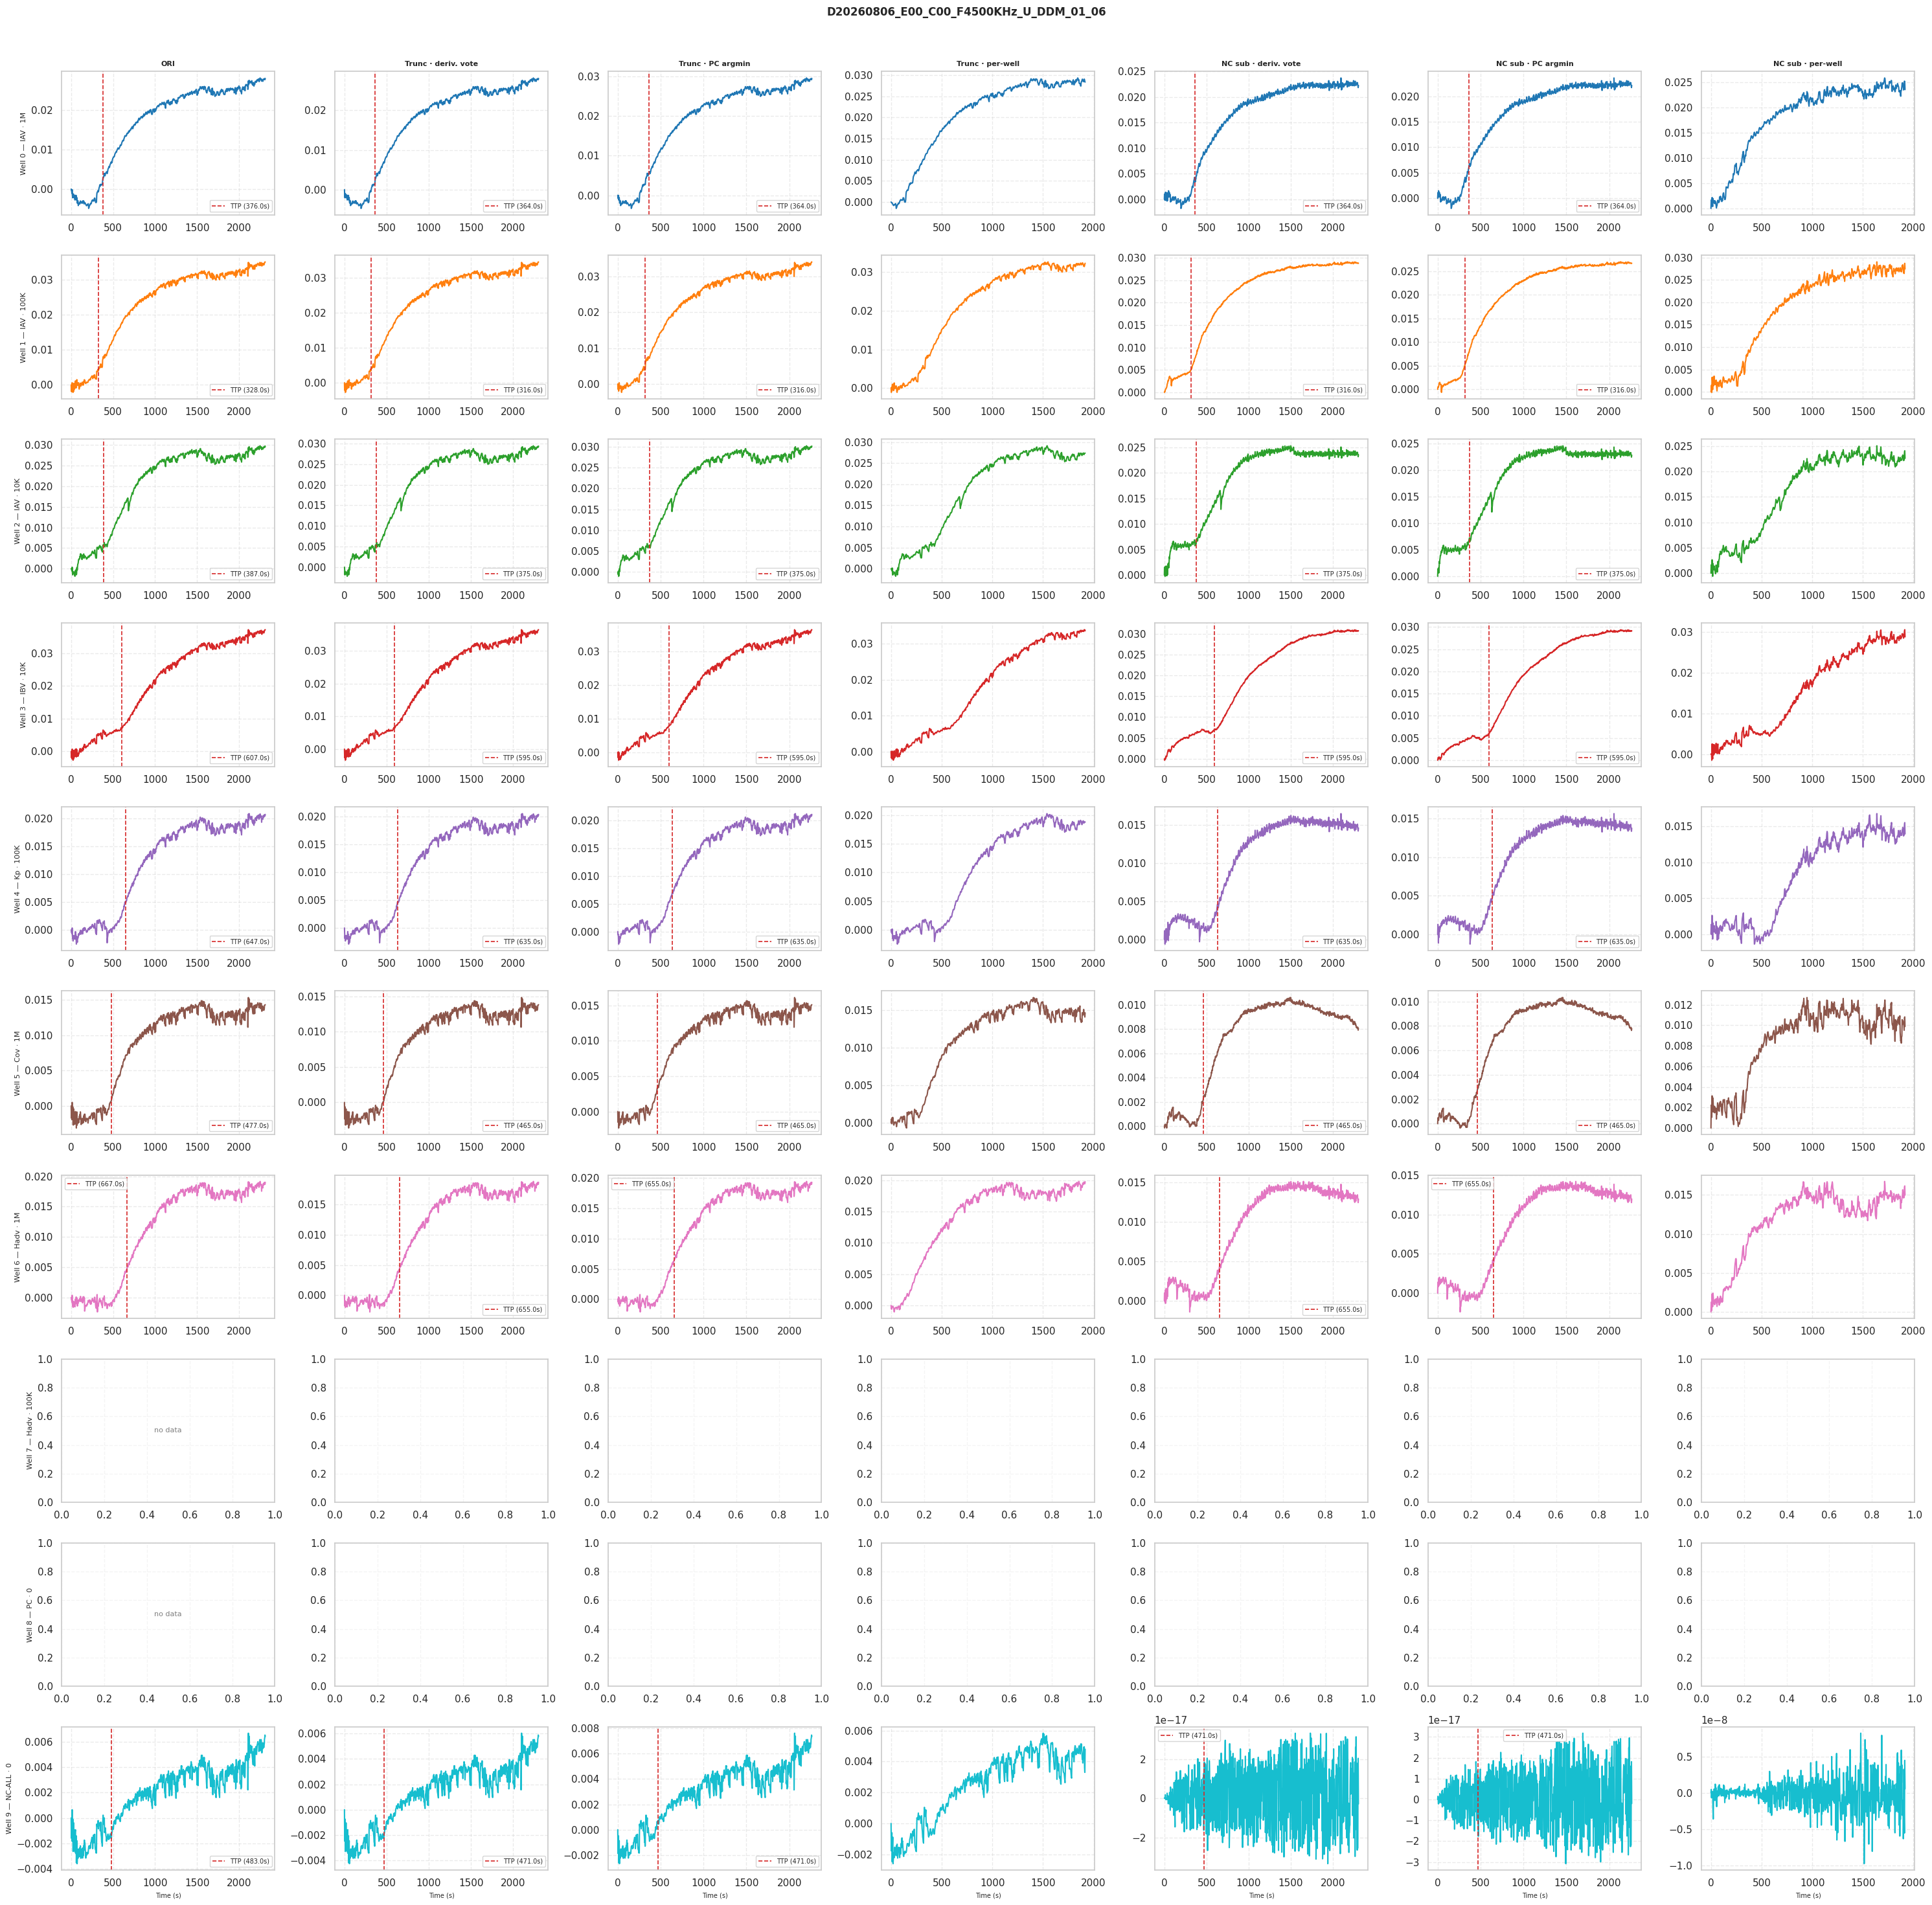

D20260807_E00_C00_F4500KHz_U_DDM_02_07
  MSI  deriv=4 (11.0s)  PC=0 (0.0s)  per-well={0: 0, 1: 25, 2: 0, 3: 5, 4: 0, 5: 4, 6: 122, 7: 5, 9: 0}


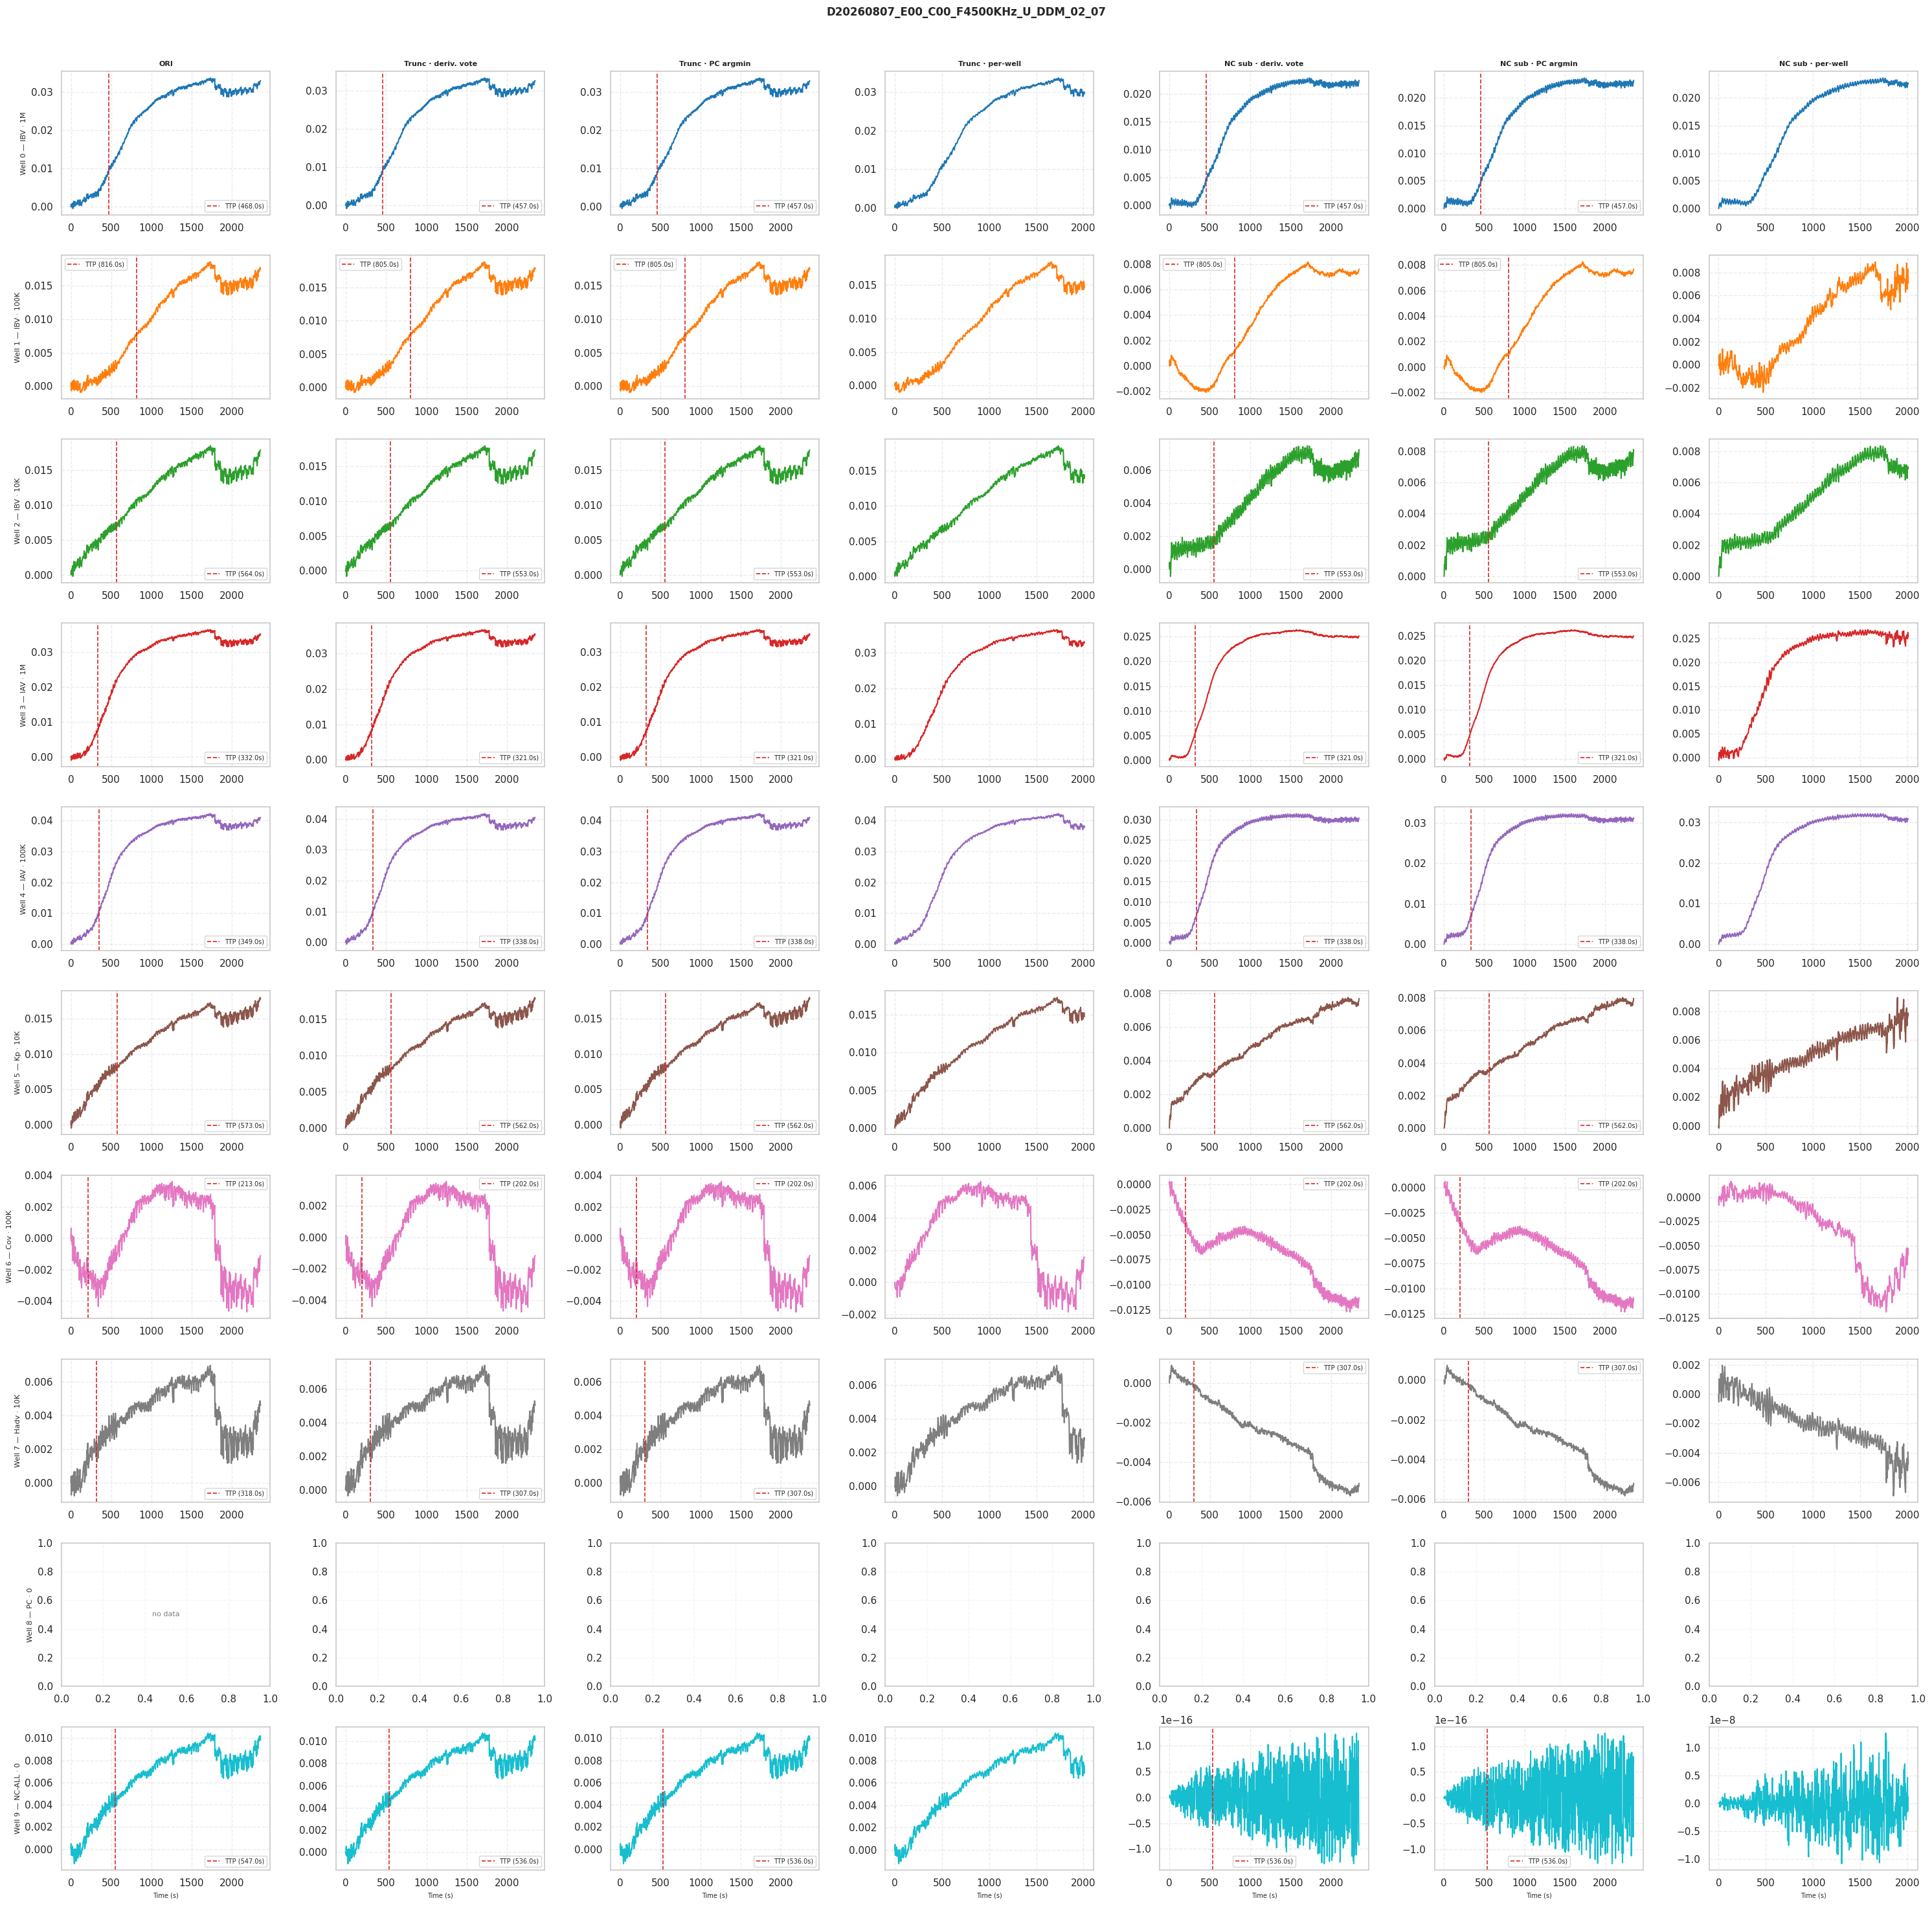

D20260808_E00_C00_F4500KHz_U_DDM_03_01
  MSI  deriv=3 (17.0s)  PC=37 (212.0s)  per-well={0: 10, 1: 21, 2: 21, 3: 17, 4: 32, 5: 41, 6: 58, 7: 57, 9: 37}


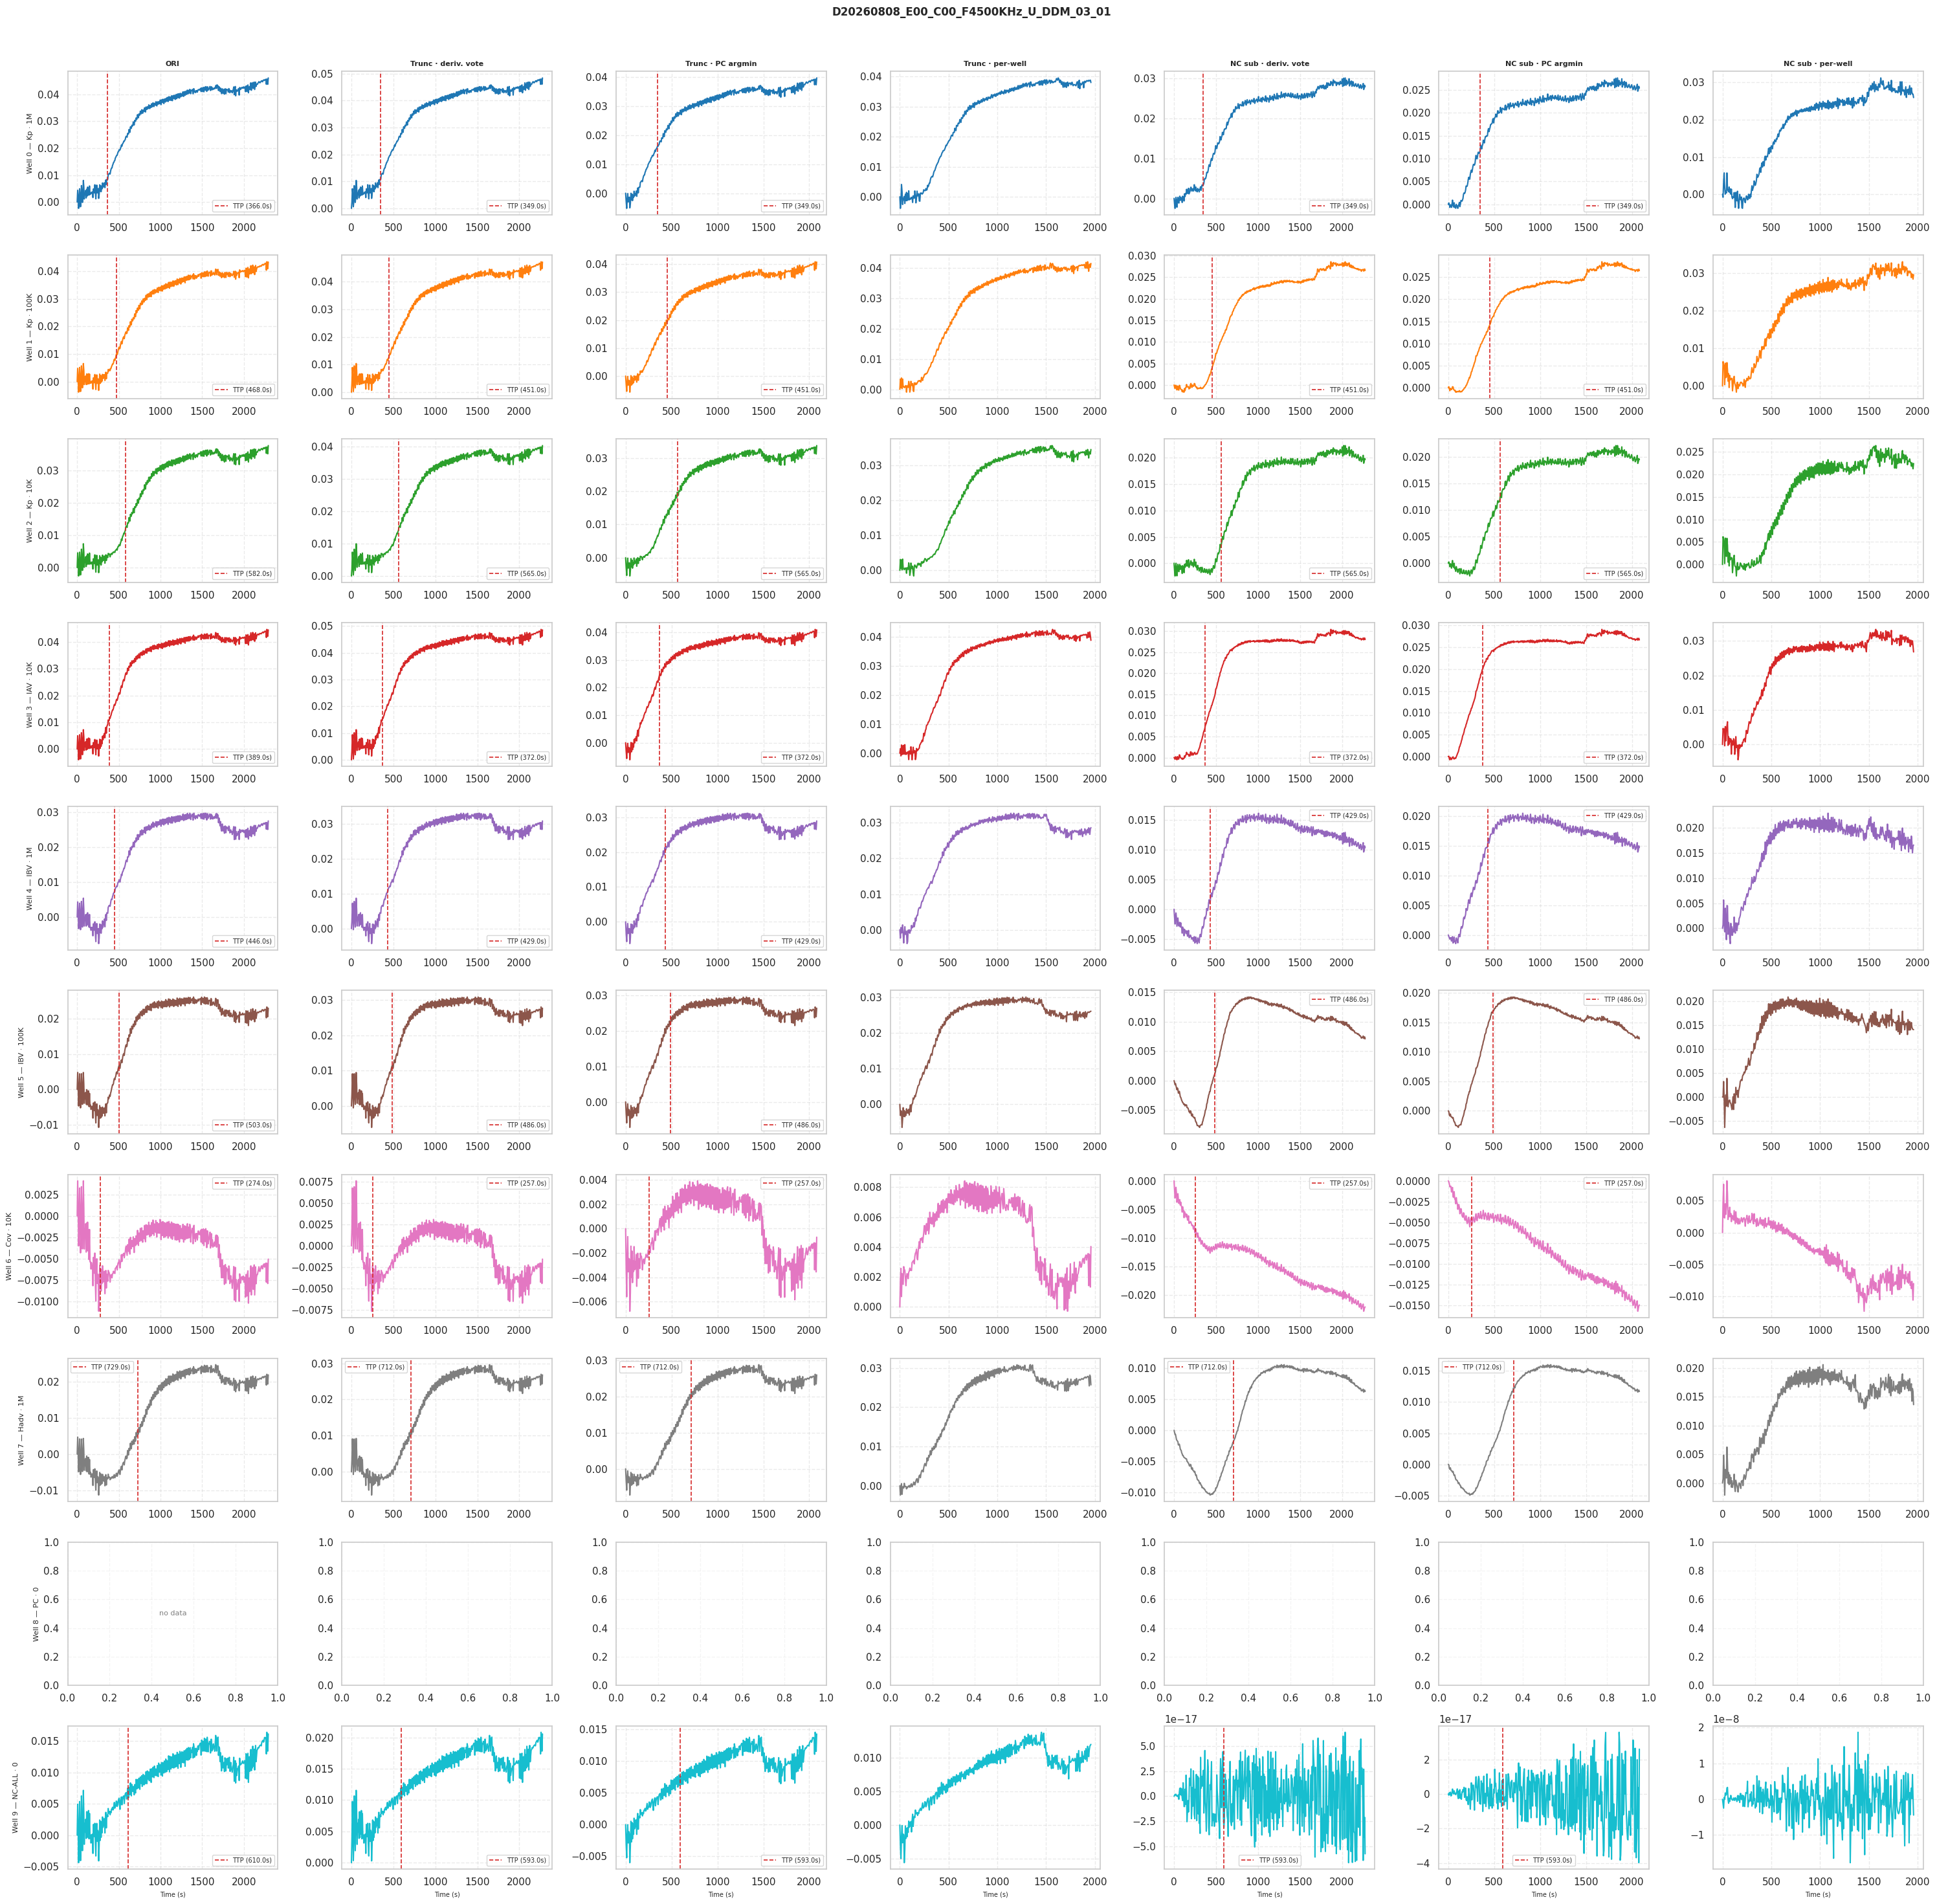

In [29]:
from scipy.ndimage import uniform_filter1d

# ── Helpers ──────────────────────────────────────────────────────────────────

def _fmt_conc(v):
    if v is None: return ''
    if v >= 1_000_000: return f'{v // 1_000_000}M'
    if v >= 1_000: return f'{v // 1_000}K'
    return str(v)

def _guard_msi(msi, n_total, tail=100):
    """Return None if msi is too close to the end to be useful."""
    return msi if (msi is not None and (msi + 1) < (n_total - tail)) else None

def get_msi_deriv_vote(markers_df, exp_name):
    """Old method: max_significant_index stored in markers_df (derivative vote)."""
    row = markers_df[markers_df["Experiment"] == exp_name]
    if not row.empty and pd.notna(row.iloc[0]["max_significant_index"]):
        return int(row.iloc[0]["max_significant_index"])
    return None

def get_msi_pc_argmin(ori_curves, y_labels, smooth_win=20):
    """New global method: argmin of smoothed mean of PC wells (falls back to all)."""
    pc_mask = (y_labels == 'PC')
    src = ori_curves[pc_mask] if np.any(pc_mask) else ori_curves
    smoothed = uniform_filter1d(np.mean(src, axis=0).squeeze(), size=smooth_win)
    return int(np.argmin(smoothed))

def get_msi_per_well(ori_curves, y_well, y_labels, smooth_win=20):
    """Per-well MSI: each well's argmin searched in a window around pc_msi.
    Constraining to [pc_msi - margin, pc_msi + margin] prevents noise spikes elsewhere
    (too early or too late) from capturing the argmin on single-well curves.
    NC* wells use pc_msi directly. Smoothing window is 3x larger for per-well
    since individual wells are noisier than the pooled PC mean."""
    T          = ori_curves.shape[1]
    pc_msi     = get_msi_pc_argmin(ori_curves, y_labels, smooth_win)
    pw_smooth  = smooth_win * 3
    margin     = max(200, pc_msi // 2)
    s_start    = max(0,       pc_msi - margin)
    s_end      = min(T - 100, pc_msi + margin)
    result = {}
    for wid in np.unique(y_well):
        mask = (y_well == wid)
        lbl  = y_labels[mask][0]
        if str(lbl).startswith('NC'):
            result[wid] = pc_msi
        else:
            smoothed = uniform_filter1d(np.mean(ori_curves[mask], axis=0).squeeze(), size=pw_smooth)
            own_msi  = s_start + int(np.argmin(smoothed[s_start:s_end]))
            result[wid] = own_msi
    return result

def trunc_global(ori_curves, t_rel, msi):
    """Truncate ALL curves at a single msi, rebaseline. Returns (curves, t) or (None, None)."""
    if msi is None:
        return None, None
    tr = ori_curves[:, msi:].copy()
    tr -= tr[:, 0:1]
    return tr, t_rel[msi:] - t_rel[msi]

def trunc_per_well(ori_curves, y_well, msi_dict, t_rel):
    """
    Truncate each well at its own argmin, rebaseline, then resample onto a
    common absolute time grid (same logic as CurveResampler.fit + .transform):
    duration = shortest remaining span; n_points = max pts within that span.
    Returns (resampled_curves, t_common) where t_common is in seconds.
    """
    T = ori_curves.shape[1]
    well_data = {}
    for wid, msi_w in msi_dict.items():
        msi_w = min(int(msi_w), T - 2)
        mask  = (y_well == wid)
        tr    = ori_curves[mask, msi_w:].copy(); tr -= tr[:, 0:1]
        t_w   = t_rel[msi_w:] - t_rel[msi_w]
        well_data[wid] = (mask, tr, t_w)
    duration = min(t_w[-1]               for _, _, t_w in well_data.values())
    n_points  = max(int(np.sum(t_w <= duration)) for _, _, t_w in well_data.values())
    t_common  = np.linspace(0, duration, n_points)
    result    = np.zeros((len(ori_curves), n_points), dtype=np.float32)
    for wid, (mask, tr, t_w) in well_data.items():
        for ri, curve in zip(np.where(mask)[0], tr):
            result[ri] = np.interp(t_common, t_w, curve.squeeze())
    return result, t_common

def apply_nc(curves, y_labels):
    """NC subtraction (no VREF split). Handles NC-ALL and per-label NC-X."""
    result = curves.copy()
    unique_labels = set(np.unique(y_labels).tolist())
    if 'NC-ALL' in unique_labels:
        result -= np.mean(curves[y_labels == 'NC-ALL'], axis=0)
    else:
        seen = set()
        for lbl in np.unique(y_labels):
            b_lbl  = str(lbl).replace('NC-', '')
            nc_lbl = f'NC-{b_lbl}'
            if b_lbl in seen or b_lbl not in unique_labels or nc_lbl not in unique_labels:
                continue
            seen.add(b_lbl)
            nc_mask  = (y_labels == nc_lbl)
            tgt_mask = (y_labels == b_lbl) | nc_mask
            if np.any(nc_mask):
                result[tgt_mask] -= np.mean(curves[nc_mask], axis=0)
    return result

# ── Plot helpers ──────────────────────────────────────────────────────────────

def _draw(ax, t_axis, curves, well_mask, color, ttp_abs=None):
    mean = np.mean(curves[well_mask], axis=0).squeeze()
    ax.plot(t_axis, mean, color=color, lw=1.5)
    if ttp_abs is not None and pd.notna(ttp_abs) and ttp_abs >= t_axis[0]:
        ax.axvline(ttp_abs, color="tab:red", linestyle="--", lw=1.2,
                   label=f"TTP ({ttp_abs:.1f}s)")
        ax.legend(fontsize=7)
    ax.grid(True, linestyle="--", alpha=0.4)

def _draw_or_missing(ax, t_axis, curves, well_mask, color, ttp_abs=None):
    if curves is None:
        ax.text(0.5, 0.5, "MSI not found", transform=ax.transAxes,
                ha="center", va="center", color="gray", fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.4)
    else:
        _draw(ax, t_axis, curves, well_mask, color, ttp_abs)

# ── Main loop ─────────────────────────────────────────────────────────────────

SMOOTH_WIN = 20
COL_LABELS = [
    "ORI",
    "Trunc \xb7 deriv. vote",
    "Trunc \xb7 PC argmin",
    "Trunc \xb7 per-well",
    "NC sub \xb7 deriv. vote",
    "NC sub \xb7 PC argmin",
    "NC sub \xb7 per-well",
]
cmap = plt.cm.tab10

for exp_name in summary_df["Experiment"].unique():
    print(exp_name)

    data_path_ori = RAW_ROOT / exp_name / config.TRAINING_DATA_PATH
    if not data_path_ori.exists():
        print(f"  [!] {exp_name}: ORI data not found, skipping."); continue

    data_ori = joblib.load(data_path_ori)
    ds_ori   = list(data_ori["dataset_name"])
    if "ori_curves" not in ds_ori:
        print(f"  [!] {exp_name}: 'ori_curves' missing, skipping."); continue

    ori_curves = data_ori["dataset"][ds_ori.index("ori_curves")]
    y_well     = np.array(data_ori["Y_well"])
    t_rel      = np.array(data_ori["timestamps"]); t_rel = t_rel - t_rel[0]
    T          = ori_curves.shape[1]

    mapping  = config.LABEL_MAPPINGS.get(exp_name, {})
    y_labels = np.array([mapping.get(int(w), str(w)) for w in y_well])
    conc_map = getattr(config, "CONC_MAPPINGS", {}).get(exp_name, {})
    exp_pw   = per_well_df[per_well_df["Experiment"] == exp_name]

    # ── Compute truncation indices ────────────────────────────────────────────
    msi_dv  = _guard_msi(get_msi_deriv_vote(markers_df, exp_name), T)
    msi_pc  = _guard_msi(get_msi_pc_argmin(ori_curves, y_labels, SMOOTH_WIN), T)
    msi_pw  = get_msi_per_well(ori_curves, y_well, y_labels, SMOOTH_WIN)
    t_msi_dv = float(t_rel[msi_dv]) if msi_dv is not None else 0.0
    t_msi_pc = float(t_rel[msi_pc]) if msi_pc is not None else 0.0
    print(f"  MSI  deriv={msi_dv} ({t_msi_dv:.1f}s)  PC={msi_pc} ({t_msi_pc:.1f}s)"
          f"  per-well={msi_pw}")

    # ── Build truncated & NC-subtracted arrays ────────────────────────────────
    tr_dv, t_dv = trunc_global(ori_curves, t_rel, msi_dv)
    tr_pc, t_pc = trunc_global(ori_curves, t_rel, msi_pc)
    tr_pw, t_pw = trunc_per_well(ori_curves, y_well, msi_pw, t_rel)

    nc_dv = apply_nc(tr_dv, y_labels) if tr_dv is not None else None
    nc_pc = apply_nc(tr_pc, y_labels) if tr_pc is not None else None
    nc_pw = apply_nc(tr_pw, y_labels)

    # ── Plot ──────────────────────────────────────────────────────────────────
    N_ROWS = 10
    all_well_ids = list(range(0, N_ROWS))
    fig, axes = plt.subplots(N_ROWS, 7, figsize=(30, 3 * N_ROWS), squeeze=False)
    fig.suptitle(exp_name, fontsize=12, fontweight="bold")
    for col, name in enumerate(COL_LABELS):
        axes[0, col].set_title(name, fontsize=8, fontweight="bold")

    for i, well_id in enumerate(all_well_ids):
        lbl      = mapping.get(int(well_id), str(well_id))
        conc_val = conc_map.get(int(well_id), None)
        conc_str = f" \xb7 {_fmt_conc(conc_val)}" if conc_val is not None else ""
        wm       = (y_well == well_id)
        color    = cmap(i % 10)

        axes[i, 0].set_ylabel(f"Well {well_id} — {lbl}{conc_str}", fontsize=8, labelpad=4)

        if not np.any(wm):
            axes[i, 0].text(0.5, 0.5, "no data", transform=axes[i, 0].transAxes,
                            ha="center", va="center", color="gray", fontsize=8)
            for ax in axes[i]:
                ax.grid(True, linestyle="--", alpha=0.2)
            continue

        pw_row = exp_pw[exp_pw["Well_ID"] == well_id]
        if not pw_row.empty:
            ttp = pw_row.iloc[0]["t_idx_TTP"] - pw_row.iloc[0]["t_idx_settled_adjusted"]
        else:
            sr  = summary_df[summary_df["Experiment"] == exp_name]
            ttp = sr.iloc[0]["t_idx_TTP_from_settled_adjusted"] if not sr.empty else np.nan

        ttp_ori_dv = (ttp + t_msi_dv) if pd.notna(ttp) else np.nan
        ttp_ori_pc = (ttp + t_msi_pc) if pd.notna(ttp) else np.nan

        _draw(axes[i, 0], t_rel, ori_curves, wm, color, ttp_ori_dv)
        _draw_or_missing(axes[i, 1], t_dv, tr_dv, wm, color, ttp)
        _draw_or_missing(axes[i, 2], t_pc, tr_pc, wm, color, ttp)
        _draw(axes[i, 3], t_pw, tr_pw, wm, color)
        _draw_or_missing(axes[i, 4], t_dv, nc_dv, wm, color, ttp)
        _draw_or_missing(axes[i, 5], t_pc, nc_pc, wm, color, ttp)
        _draw(axes[i, 6], t_pw, nc_pw, wm, color)

    for col in range(7):
        axes[-1, col].set_xlabel("Time (s)", fontsize=7)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [30]:
from scipy.ndimage import uniform_filter1d


def _fmt_conc_v(v):
    if v is None: return "N/A"
    v = int(v)
    if v >= 1_000_000: return f"{v // 1_000_000}M"
    if v >= 1_000:     return f"{v // 1_000}K"
    return str(v)


def plot_label_conc_grid(
    exp_names,
    data_root=None,
    curve_key="ori_curves",
    nc_subtract=False,
    normalize_time=False,
    normalize_values=False,
    smooth_win=None,
    n_resample=500,
    conc_order=None,
    label_order=None,
    figsize_per_cell=(4, 3),
    title=None,
    alpha=0.85,
):
    """
    Grid: rows = labels (NC, PC, iAV …), columns = concentrations.
    Each cell plots one mean curve per experiment (color-coded).

    Parameters
    ----------
    exp_names        : list[str]  experiments to overlay
    data_root        : Path       root folder (default RAW_ROOT)
    curve_key        : str        dataset variant ('ori_curves', 'ori_curves_wavelet_bior35' …)
    nc_subtract      : bool       apply PC-argmin truncation then NC subtraction before plotting
    normalize_time   : bool       rescale each experiment's time axis to [0, 1]
    normalize_values : bool       min-max normalise each well's curve to [0, 1]
    smooth_win       : int|None   uniform_filter1d window applied before plotting
    n_resample       : int        common grid size (used when normalize_time=True)
    conc_order       : list|None  concentration display order; None = auto-sort ascending
    label_order      : list|None  label display order; None = auto (NC* last)
    figsize_per_cell : (w, h)    per-subplot size in inches
    title            : str|None   figure suptitle
    alpha            : float      line opacity
    """
    if data_root is None:
        data_root = RAW_ROOT

    cmap_exp  = plt.cm.tab10
    exp_color = {n: cmap_exp(i % 10) for i, n in enumerate(exp_names)}

    # ── Load: one (exp, label, conc, mean_curve, t) record per well ──────────
    records = []
    for exp_name in exp_names:
        data_path = data_root / exp_name / config.TRAINING_DATA_PATH
        if not data_path.exists():
            print(f"  [!] {exp_name}: not found, skipping.")
            continue
        data = joblib.load(data_path)
        ds   = list(data["dataset_name"])
        if curve_key not in ds:
            print(f"  [!] {exp_name}: '{curve_key}' missing, skipping.")
            continue

        curves   = data["dataset"][ds.index(curve_key)].copy()   # (N, T)
        y_well   = np.array(data["Y_well"])
        t_raw    = np.array(data["timestamps"]); t_raw -= t_raw[0]
        lbl_map  = config.LABEL_MAPPINGS.get(exp_name, {})
        conc_map = getattr(config, "CONC_MAPPINGS", {}).get(exp_name, {})
        y_labels_all = np.array([lbl_map.get(int(w), str(w)) for w in y_well])

        if nc_subtract:
            msi = get_msi_pc_argmin(curves, y_labels_all)
            if msi is not None and (msi + 1) < (len(t_raw) - 100):
                curves  = curves[:, msi:].copy(); curves -= curves[:, 0:1]
                t_raw   = t_raw[msi:] - t_raw[msi]
                print(f"  [{exp_name}] PC argmin MSI={msi}, truncated to {len(t_raw)} pts")
            curves = apply_nc(curves, y_labels_all)

        for wid in np.unique(y_well):
            mask       = (y_well == wid)
            lbl        = lbl_map.get(int(wid), str(wid))
            conc       = conc_map.get(int(wid), None)
            mean_curve = np.mean(curves[mask], axis=0).squeeze()
            if smooth_win:
                mean_curve = uniform_filter1d(mean_curve, size=smooth_win)
            if normalize_values:
                mn, mx = mean_curve.min(), mean_curve.max()
                if mx > mn:
                    mean_curve = (mean_curve - mn) / (mx - mn)
            records.append((exp_name, lbl, conc, mean_curve, t_raw))

    if not records:
        print("No data loaded — check exp_names and data_root."); return

    # ── Determine grid axes ──────────────────────────────────────────────────
    seen_labels = list(dict.fromkeys(r[1] for r in records))
    seen_concs  = sorted(set(r[2] for r in records), key=lambda v: (v is None, v or 0))

    if label_order is not None:
        all_labels = [l for l in label_order if l in seen_labels]
        # append any remaining labels not in label_order
        all_labels += [l for l in seen_labels if l not in all_labels]
    else:
        # NC* labels go last
        nc  = [l for l in seen_labels if str(l).startswith("NC")]
        nonnc = [l for l in seen_labels if not str(l).startswith("NC")]
        all_labels = sorted(nonnc) + sorted(nc)

    if conc_order is not None:
        all_concs = [c for c in conc_order if c in seen_concs]
        all_concs += [c for c in seen_concs if c not in all_concs]
    else:
        all_concs = seen_concs

    n_rows, n_cols = len(all_labels), len(all_concs)
    if n_rows == 0 or n_cols == 0:
        print("Empty grid — no matching labels or concentrations."); return

    # ── Build figure ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per_cell[0] * n_cols, figsize_per_cell[1] * n_rows),
        squeeze=False,
    )
    _flags = []
    if nc_subtract:      _flags.append("NC sub")
    if normalize_values: _flags.append("val norm")
    if normalize_time:   _flags.append("time norm")
    _flag_str = f"  [{', '.join(_flags)}]" if _flags else ""
    fig.suptitle(title or f"{curve_key}{_flag_str}  ·  label × concentration", fontsize=13, fontweight="bold")

    for ci, conc in enumerate(all_concs):
        axes[0, ci].set_title(_fmt_conc_v(conc), fontsize=10, fontweight="bold")
    for ri, lbl in enumerate(all_labels):
        axes[ri, 0].set_ylabel(lbl, fontsize=10, fontweight="bold", labelpad=6)

    # ── Plot ─────────────────────────────────────────────────────────────────
    has_data = [[False] * n_cols for _ in range(n_rows)]

    for exp_name, lbl, conc, mean_curve, t_raw in records:
        if lbl not in all_labels or conc not in all_concs:
            continue
        ri = all_labels.index(lbl)
        ci = all_concs.index(conc)
        ax = axes[ri, ci]

        if normalize_time:
            t_plot = np.linspace(0, 1, n_resample)
            curve  = np.interp(t_plot, np.linspace(0, 1, len(mean_curve)), mean_curve)
        else:
            t_plot = t_raw
            curve  = mean_curve

        ax.plot(t_plot, curve, color=exp_color[exp_name], alpha=alpha, lw=1.5, label=exp_name)
        has_data[ri][ci] = True

    # ── Style empty cells ─────────────────────────────────────────────────────
    x_label = "Norm. time [0–1]" if normalize_time else "Time (s)"
    y_label = "Value [0–1]" if normalize_values else "Signal"
    for ri in range(n_rows):
        for ci in range(n_cols):
            ax = axes[ri, ci]
            ax.grid(True, linestyle="--", alpha=0.35)
            if ri == n_rows - 1:
                ax.set_xlabel(x_label, fontsize=7)
            if not has_data[ri][ci]:
                ax.text(0.5, 0.5, "—", transform=ax.transAxes,
                        ha="center", va="center", color="lightgray", fontsize=18)

    # ── Legend ───────────────────────────────────────────────────────────────
    handles = [plt.Line2D([0], [0], color=exp_color[n], lw=2, label=n) for n in exp_names]
    fig.legend(handles=handles, loc="lower center", ncol=min(len(exp_names), 4),
               fontsize=8, bbox_to_anchor=(0.5, -0.01), frameon=True)
    plt.tight_layout(rect=[0, 0.05, 1, 0.97])
    plt.show()

In [31]:
LINESTYLES = ["-", "--", "-.", ":"]

def plot_target_consistency(
    exp_names,
    data_root=None,
    curve_key="ori_curves",
    nc_subtract=False,
    normalize_time=False,
    normalize_values=False,
    smooth_win=None,
    n_resample=500,
    label_filter=None,
    figsize=(14, 5),
    title=None,
    alpha=0.75,
    lw=1.8,
):
    """
    Single plot: one mean curve per (experiment, label) pair.
    Color  = label (target type) — consistent across experiments.
    Line style = experiment/folder — cycles through -, --, -., :
    Goal: see whether the same target produces a similar curve across folders.

    Parameters
    ----------
    exp_names      : list[str]   experiments to overlay
    data_root      : Path        root folder (default RAW_ROOT)
    curve_key      : str         dataset variant
    nc_subtract    : bool        apply PC-argmin truncation + NC subtraction first
    normalize_time : bool        rescale time axis to [0, 1]
    normalize_values : bool      min-max normalise each curve to [0, 1]
    smooth_win     : int|None    uniform_filter1d smoothing window
    n_resample     : int         common grid size when normalize_time=True
    label_filter   : list|None   show only these labels; None = all
    figsize        : tuple
    title          : str|None
    alpha, lw      : float       line style
    """
    if data_root is None:
        data_root = RAW_ROOT

    cmap_lbl  = plt.cm.tab10
    all_labels_seen = []
    lines = []   # (exp_name, label, mean_curve, t_plot)

    for exp_name in exp_names:
        data_path = data_root / exp_name / config.TRAINING_DATA_PATH
        if not data_path.exists():
            print(f"  [!] {exp_name}: not found, skipping."); continue
        data = joblib.load(data_path)
        ds   = list(data["dataset_name"])
        if curve_key not in ds:
            print(f"  [!] {exp_name}: '{curve_key}' missing, skipping."); continue

        curves      = data["dataset"][ds.index(curve_key)].copy()
        y_well      = np.array(data["Y_well"])
        t_raw       = np.array(data["timestamps"]); t_raw -= t_raw[0]
        lbl_map     = config.LABEL_MAPPINGS.get(exp_name, {})
        y_labels_all = np.array([lbl_map.get(int(w), str(w)) for w in y_well])

        if nc_subtract:
            msi = get_msi_pc_argmin(curves, y_labels_all)
            if msi is not None and (msi + 1) < (len(t_raw) - 100):
                curves  = curves[:, msi:].copy(); curves -= curves[:, 0:1]
                t_raw   = t_raw[msi:] - t_raw[msi]
            curves = apply_nc(curves, y_labels_all)

        for lbl in np.unique(y_labels_all):
            if label_filter is not None and lbl not in label_filter:
                continue
            mask = (y_labels_all == lbl)
            mean_curve = np.mean(curves[mask], axis=0).squeeze()
            if smooth_win:
                mean_curve = uniform_filter1d(mean_curve, size=smooth_win)
            if normalize_values:
                mn, mx = mean_curve.min(), mean_curve.max()
                if mx > mn: mean_curve = (mean_curve - mn) / (mx - mn)
            if normalize_time:
                t_plot = np.linspace(0, 1, n_resample)
                mean_curve = np.interp(t_plot, np.linspace(0, 1, len(mean_curve)), mean_curve)
            else:
                t_plot = t_raw
            lines.append((exp_name, lbl, mean_curve, t_plot))
            if lbl not in all_labels_seen:
                all_labels_seen.append(lbl)

    if not lines:
        print("No data."); return

    # stable label order: non-NC first, NC* last
    nc_lbls    = sorted(l for l in all_labels_seen if str(l).startswith("NC"))
    non_nc     = sorted(l for l in all_labels_seen if not str(l).startswith("NC"))
    all_labels = non_nc + nc_lbls
    lbl_color  = {l: cmap_lbl(i % 10) for i, l in enumerate(all_labels)}
    exp_ls     = {n: LINESTYLES[i % len(LINESTYLES)] for i, n in enumerate(exp_names)}

    fig, ax = plt.subplots(figsize=figsize)
    for exp_name, lbl, mean_curve, t_plot in lines:
        ax.plot(t_plot, mean_curve,
                color=lbl_color[lbl], ls=exp_ls[exp_name],
                lw=lw, alpha=alpha)

    ax.grid(True, linestyle="--", alpha=0.35)
    ax.set_xlabel("Norm. time [0–1]" if normalize_time else "Time (s)", fontsize=9)
    ax.set_ylabel("Value [0–1]" if normalize_values else "Signal", fontsize=9)

    _flags = [f for f, v in [("NC sub", nc_subtract), ("val norm", normalize_values),
                               ("time norm", normalize_time)] if v]
    ax.set_title(title or f"{curve_key}  ·  target consistency across experiments"
                 + (f"  [{', '.join(_flags)}]" if _flags else ""), fontsize=11)

    # two-part legend: label colors | experiment linestyles
    lbl_handles = [plt.Line2D([0],[0], color=lbl_color[l], lw=2.5, label=l) for l in all_labels]
    exp_handles = [plt.Line2D([0],[0], color="gray", ls=exp_ls[n], lw=2, label=n) for n in exp_names]
    leg1 = ax.legend(handles=lbl_handles, title="Target", loc="upper left",
                     fontsize=8, title_fontsize=8, framealpha=0.8)
    ax.add_artist(leg1)
    ax.legend(handles=exp_handles, title="Experiment", loc="upper right",
              fontsize=7, title_fontsize=8, framealpha=0.8)

    plt.tight_layout()
    plt.show()


In [32]:
list(well_agg_df.Label.unique())

['IAV', 'IBV', 'Kp', 'Cov', 'Hadv', 'NC-ALL']

In [41]:
exp_to_show = ["D20260806_E00_C00_F4500KHz_U_DDM_01_06", "D20260807_E00_C00_F4500KHz_U_DDM_02_07", "D20260808_E00_C00_F4500KHz_U_DDM_03_01"]

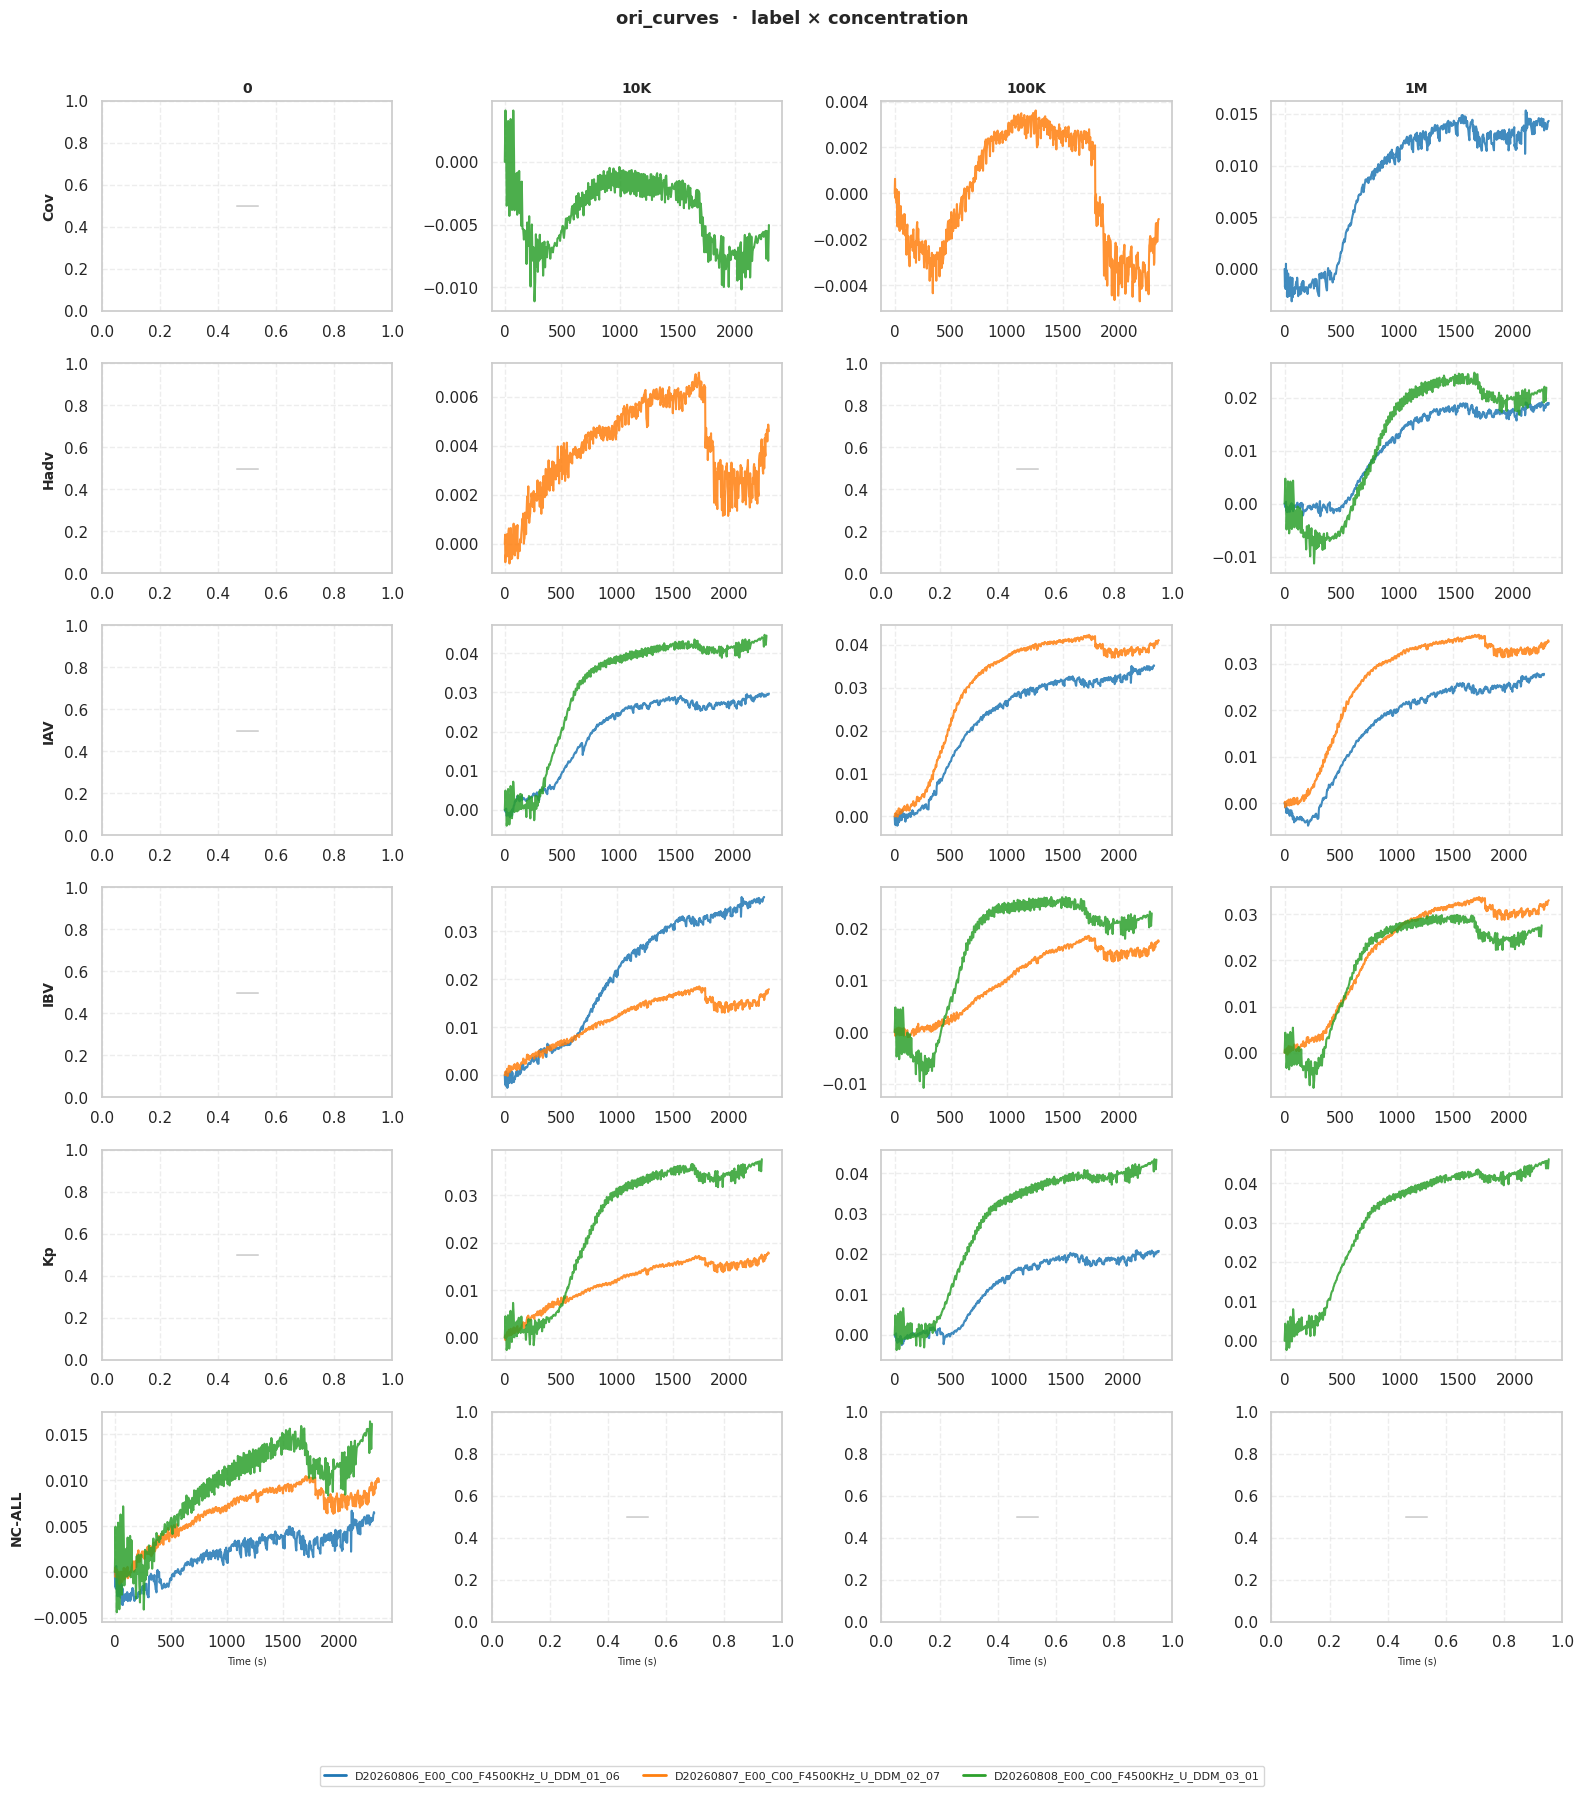

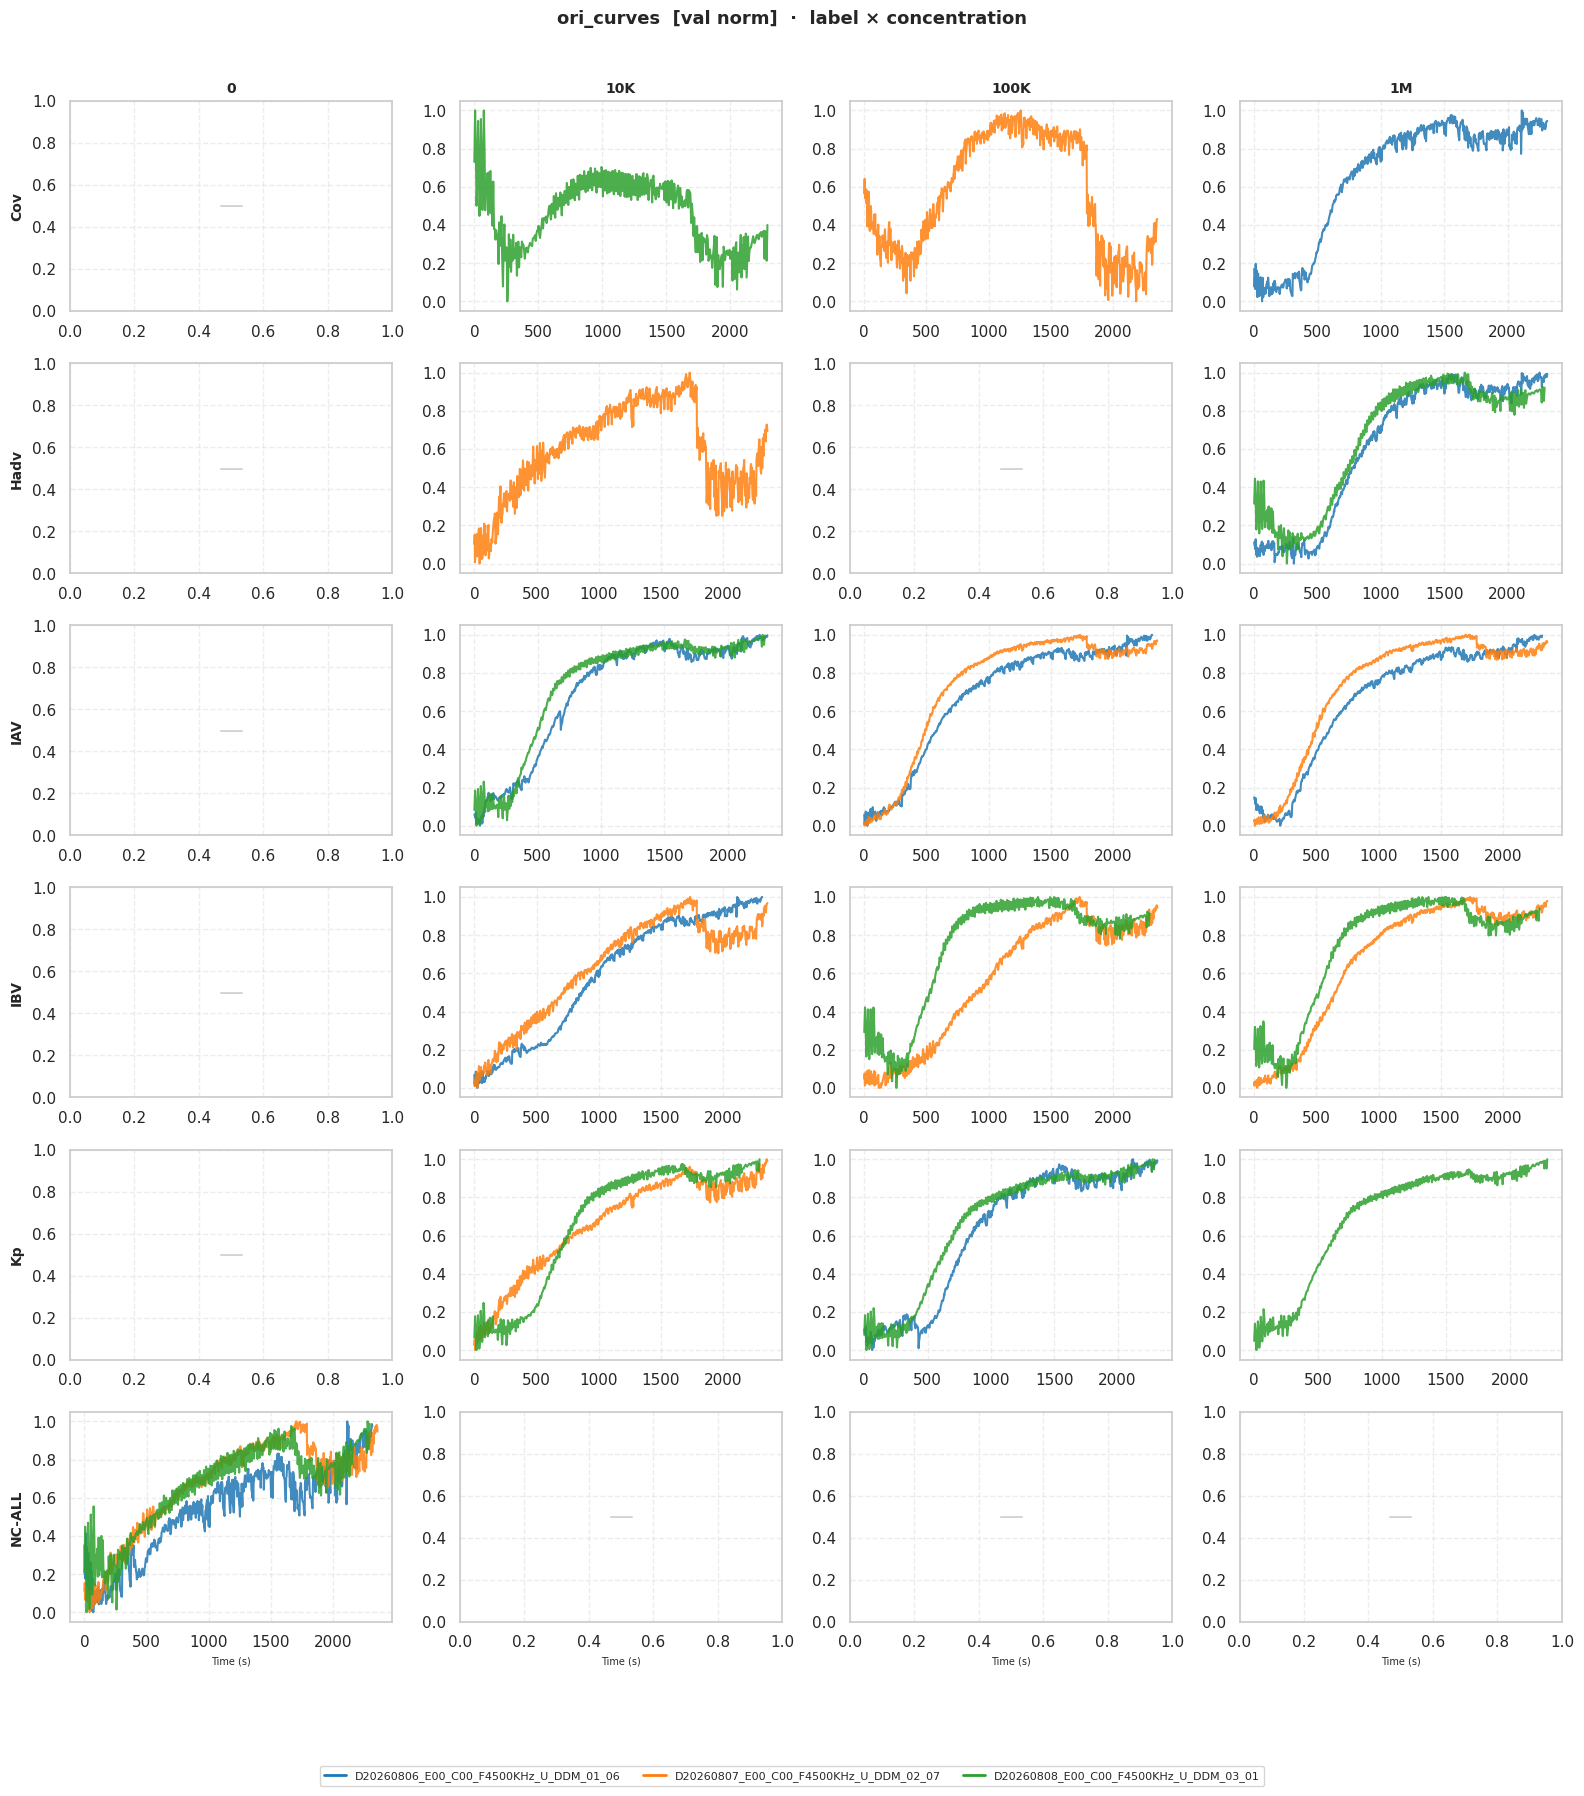

: 

In [ ]:
plot_label_conc_grid(
    exp_names=exp_to_show,
    nc_subtract=False,
    normalize_values=False
)

plot_label_conc_grid(
    exp_names=exp_to_show,
    nc_subtract=False,
    normalize_values=True
)

  [D20260806_E00_C00_F4500KHz_U_DDM_01_06] PC argmin MSI=18, truncated to 795 pts
  [D20260807_E00_C00_F4500KHz_U_DDM_02_07] PC argmin MSI=0, truncated to 827 pts
  [D20260808_E00_C00_F4500KHz_U_DDM_03_01] PC argmin MSI=37, truncated to 366 pts


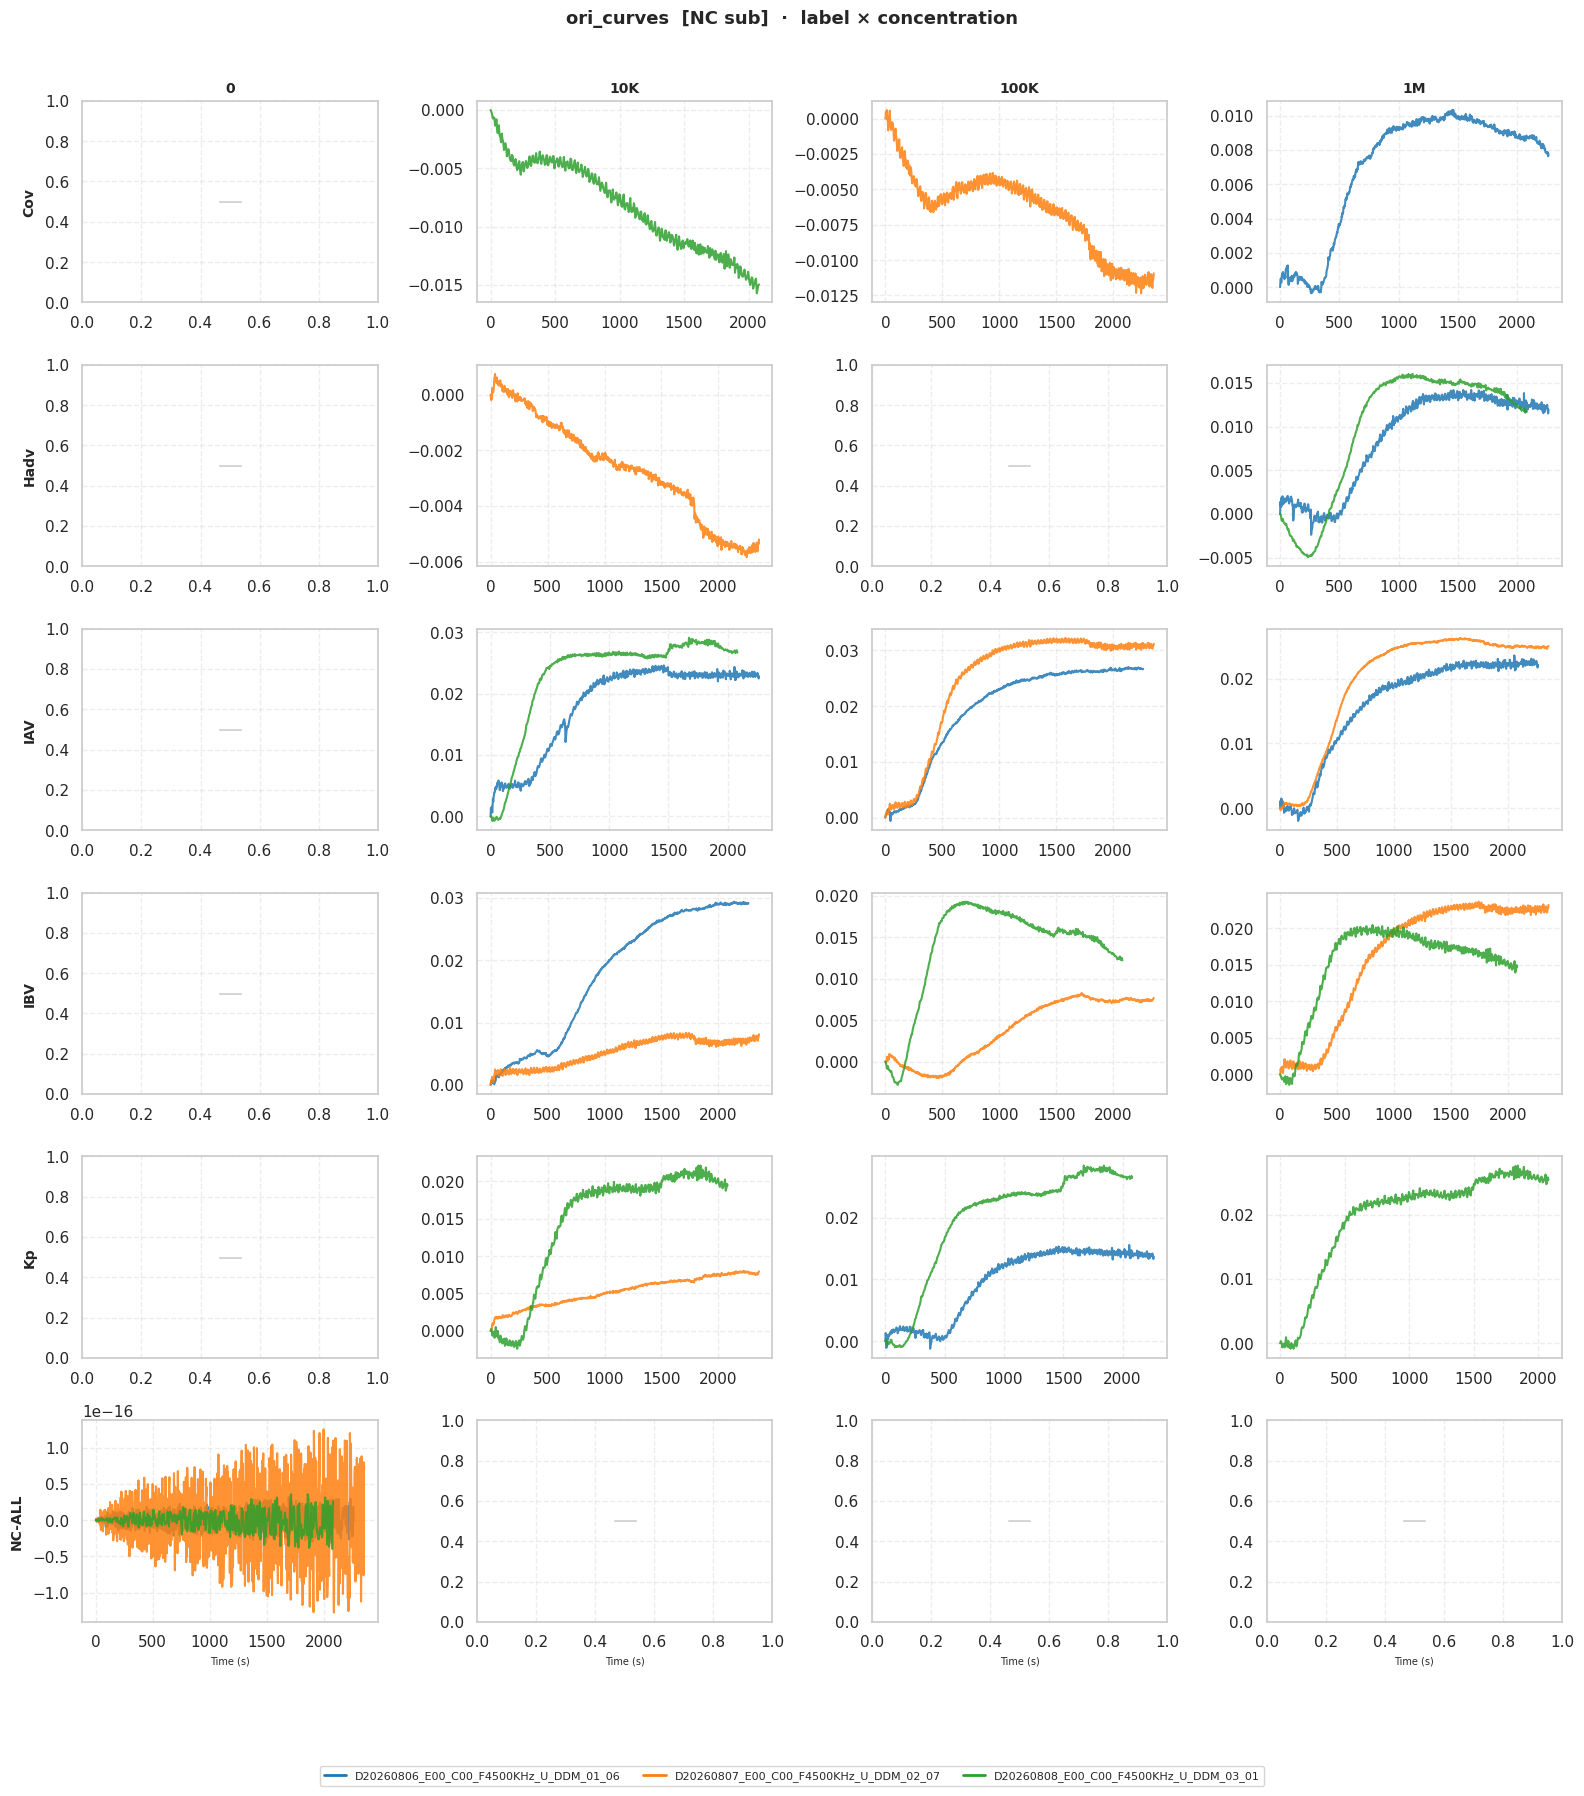

  [D20260806_E00_C00_F4500KHz_U_DDM_01_06] PC argmin MSI=18, truncated to 795 pts
  [D20260807_E00_C00_F4500KHz_U_DDM_02_07] PC argmin MSI=0, truncated to 827 pts
  [D20260808_E00_C00_F4500KHz_U_DDM_03_01] PC argmin MSI=37, truncated to 366 pts


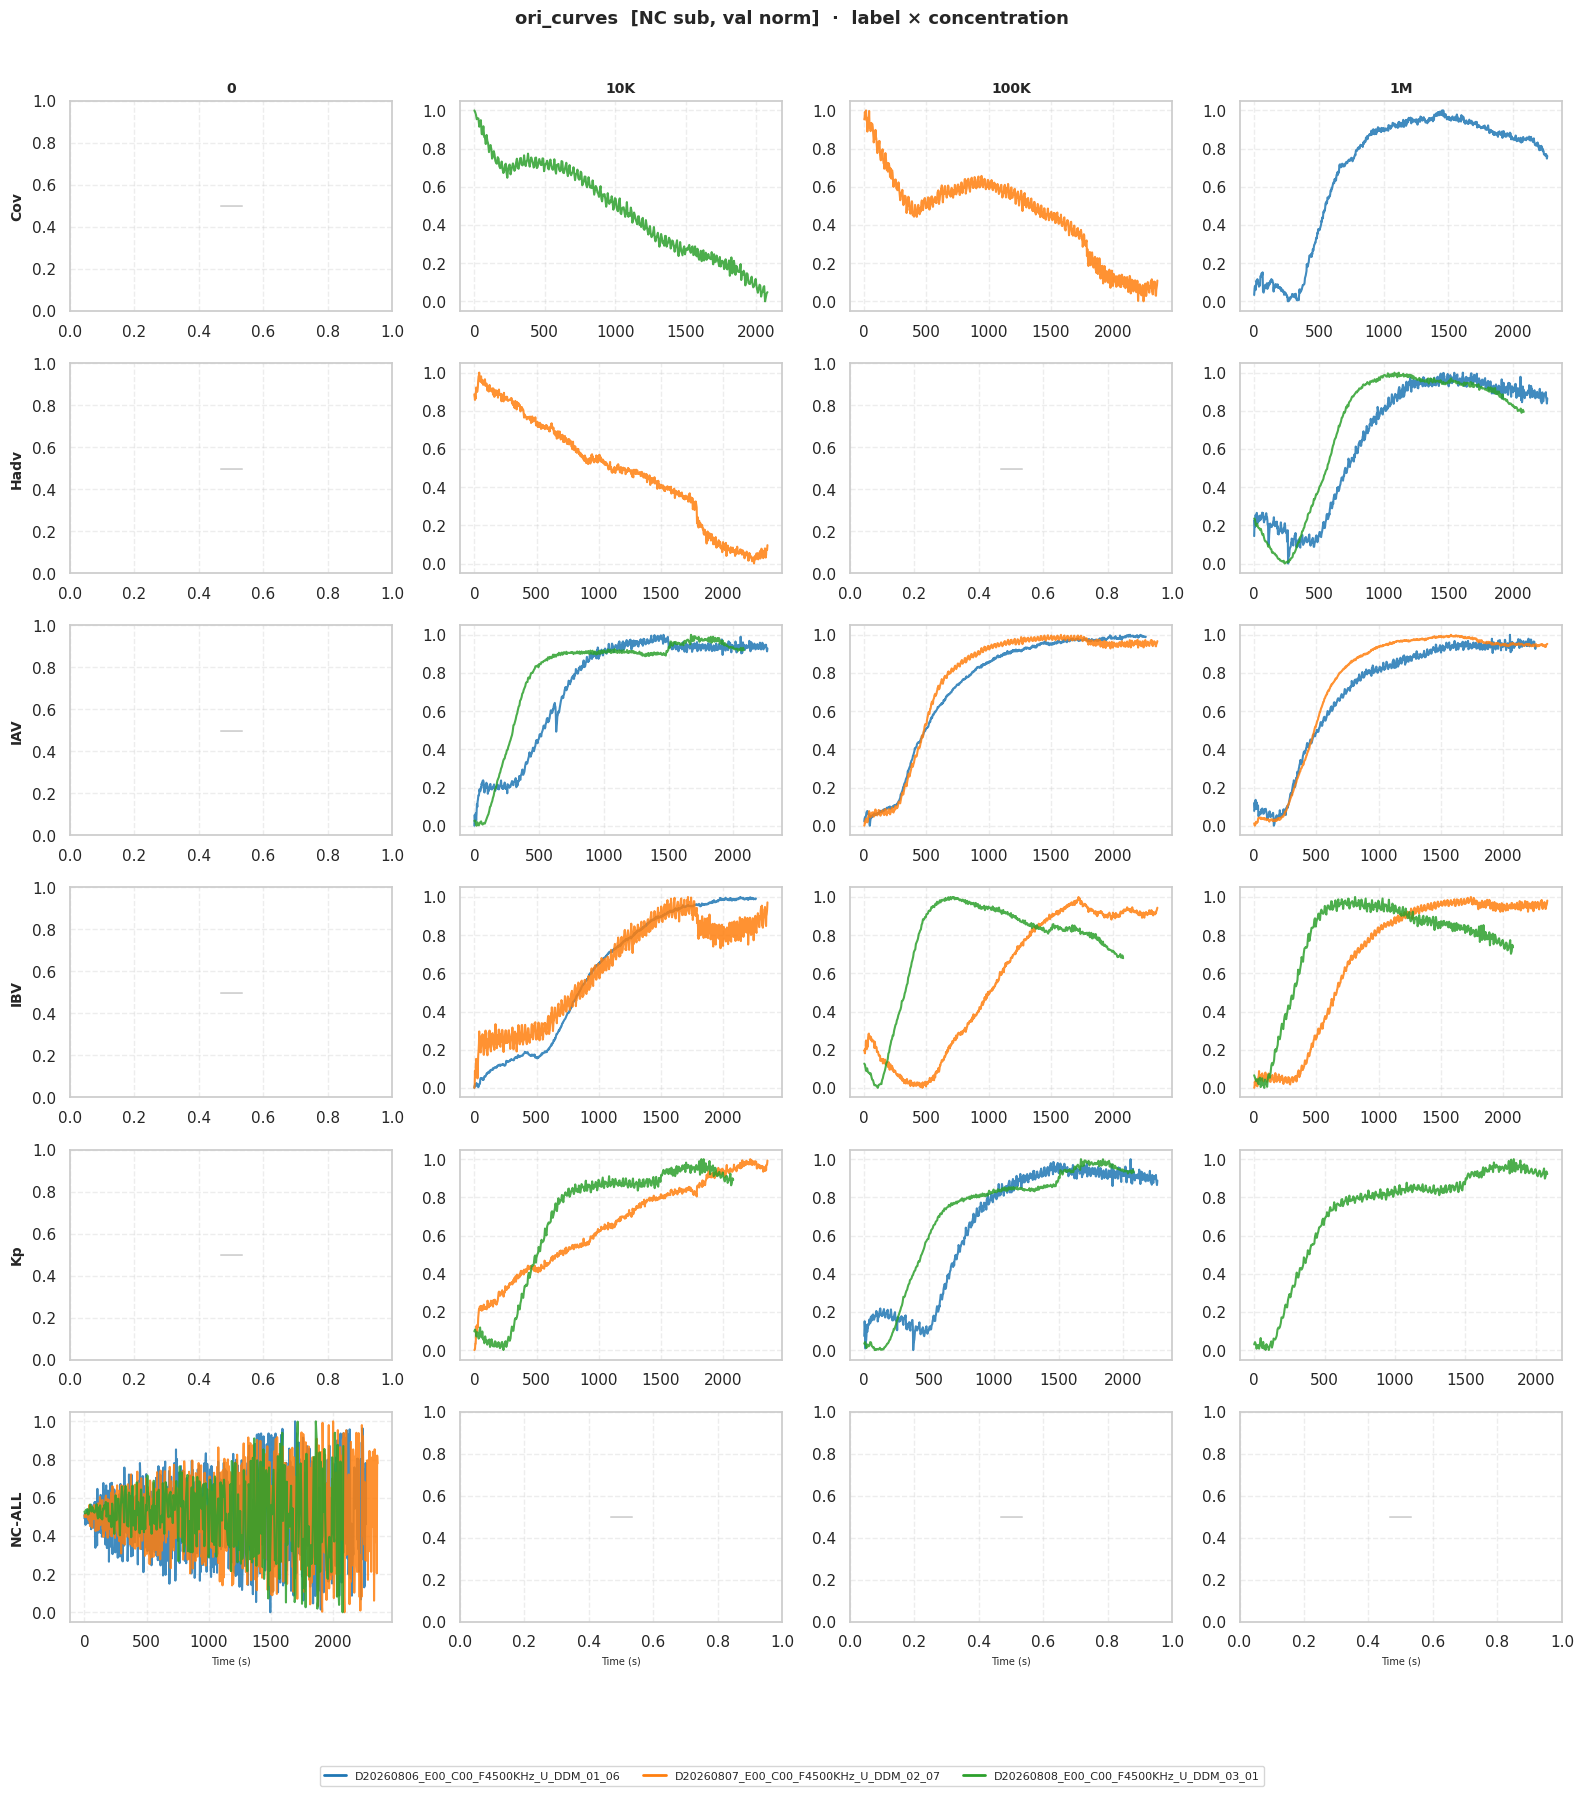

In [43]:
plot_label_conc_grid(
    exp_names=exp_to_show,
    nc_subtract=True,
    normalize_values=False
)

plot_label_conc_grid(
    exp_names=exp_to_show,
    nc_subtract=True,
    normalize_values=True
)

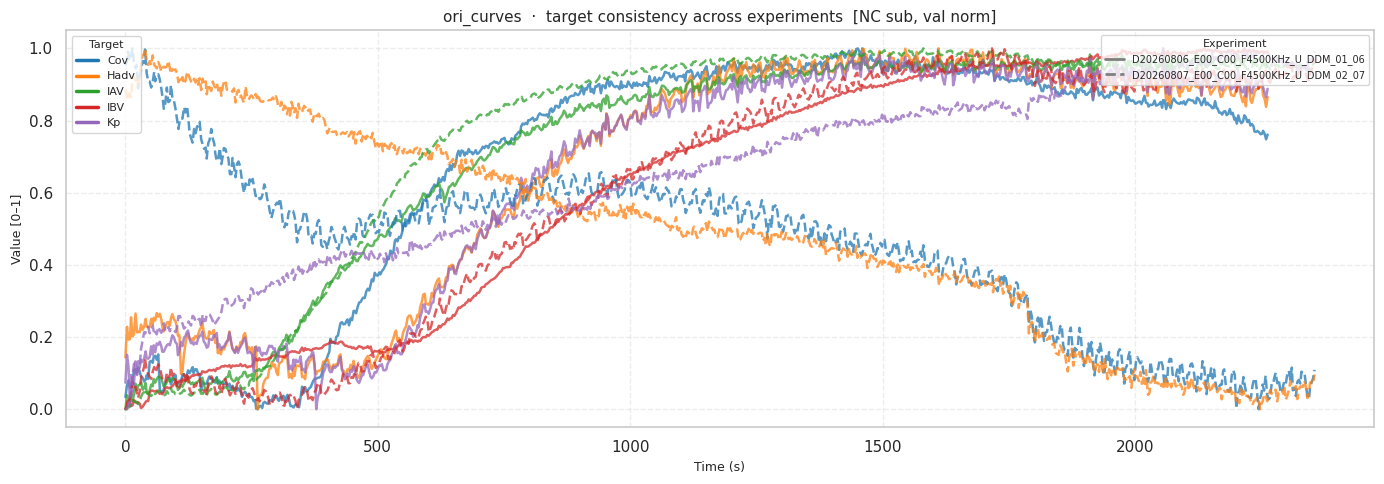

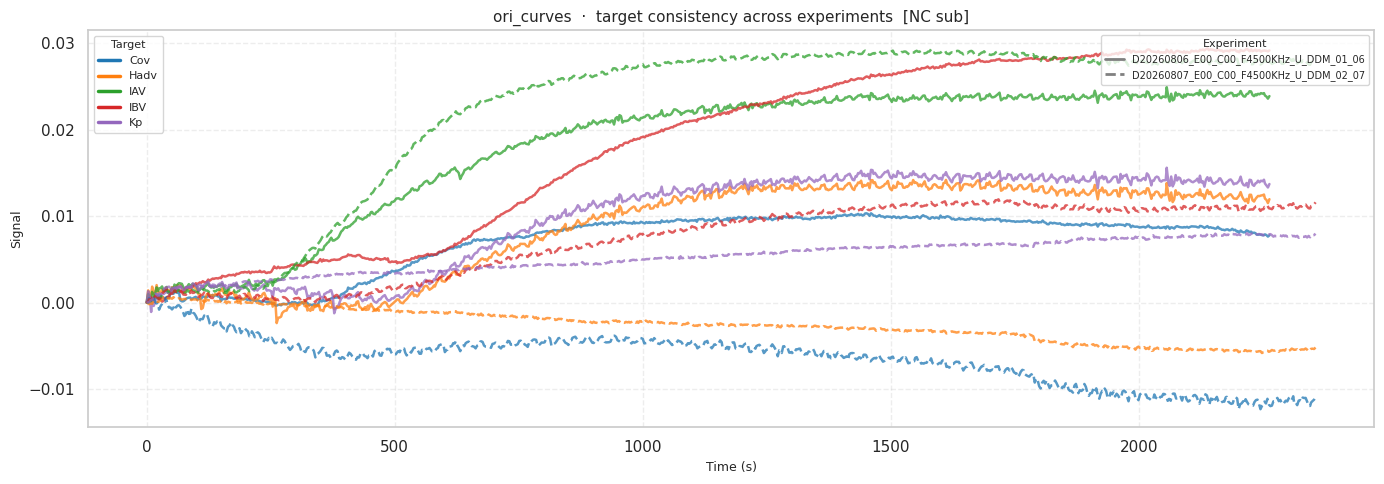

In [35]:

plot_target_consistency(
    exp_names=["D20260806_E00_C00_F4500KHz_U_DDM_01_06", "D20260807_E00_C00_F4500KHz_U_DDM_02_07"],
    nc_subtract=True, normalize_values=True, label_filter=['IAV', 'IBV', 'Kp', 'Cov', 'Hadv']
)


plot_target_consistency(
    exp_names=["D20260806_E00_C00_F4500KHz_U_DDM_01_06", "D20260807_E00_C00_F4500KHz_U_DDM_02_07"],
    nc_subtract=True, normalize_values=False, label_filter=['IAV', 'IBV', 'Kp', 'Cov', 'Hadv']
)

In [36]:
# for exp_name in summary_df["Experiment"].unique():
#     print(exp_name)
#     data_path = NC_SUBTRACT_ROOT / exp_name / config.TRAINING_DATA_PATH
#     if not data_path.exists():
#         print(f"  [!] {exp_name}: {config.TRAINING_DATA_PATH} not found, skipping.")
#         continue

#     data = joblib.load(data_path)
#     ds_names = list(data["dataset_name"])
#     if "ori_curves" not in ds_names:
#         print(f"  [!] {exp_name}: 'ori_curves' not in dataset, skipping.")
#         continue

#     ds_idx = ds_names.index("ori_curves")
#     ori_curves = data["dataset"][ds_idx]
#     y_well = np.array(data["Y_well"])
#     saved_ts = np.array(data["timestamps"])
#     t_rel = saved_ts - saved_ts[0]

#     label_mappings = config.get_label_mappings(NC_SUBTRACT_ROOT / exp_name)
#     mapping = label_mappings.get(exp_name, {})

#     exp_pw = per_well_df[per_well_df["Experiment"] == exp_name]
#     unique_wells = sorted(np.unique(y_well))
#     n_wells = len(unique_wells)

#     fig, axes = plt.subplots(n_wells, 1, figsize=(14, 3 * n_wells), squeeze=False)
#     fig.suptitle(f"{exp_name}  [ori_curve · x=0 at idx_settled_adjusted]",
#                  fontsize=12, fontweight="bold")

#     for i, well_id in enumerate(unique_wells):
#         ax = axes[i, 0]
#         lbl = mapping.get(int(well_id), str(well_id))
#         well_mask = (y_well == well_id)
#         well_curves = ori_curves[well_mask]
#         color = cmap(i % 10)

#         for curve in well_curves:
#             ax.plot(t_rel, curve.squeeze(), color=color, lw=0.5, alpha=0.15)
#         ax.plot(t_rel, np.mean(well_curves, axis=0).squeeze(), color=color, lw=2.0,
#                 label=f"mean (n={well_mask.sum()})")

#         pw_row = exp_pw[exp_pw["Well_ID"] == well_id]
#         if not pw_row.empty:
#             ttp_t = pw_row.iloc[0]["t_idx_TTP"] - pw_row.iloc[0]["t_idx_settled_adjusted"]
#         else:
#             summary_row = summary_df[summary_df["Experiment"] == exp_name]
#             ttp_t = summary_row.iloc[0]["t_idx_TTP_from_settled_adjusted"] if not summary_row.empty else np.nan

#         if pd.notna(ttp_t):
#             ax.axvline(ttp_t, color="tab:red", linestyle="--", lw=1.5,
#                        label=f"TTP ({ttp_t:.1f}s)")

#         ax.set_title(f"Well {well_id} — {lbl}", fontsize=10, fontweight="bold")
#         ax.set_xlabel("Time from nc_subtract start (s)")
#         ax.set_ylabel("Signal")
#         ax.legend(fontsize=8)
#         ax.grid(True, linestyle="--", alpha=0.4)

#     plt.tight_layout()
#     plt.show()


In [37]:
# def shorten_label(name):
#     return name.split("temp_")[-1] if "temp_" in name else name


# def plot_ttp_vs_marker(summary_df, marker_col):
#     plot_df = summary_df.sort_values("Experiment").copy()
#     plot_df["Experiment_short"] = plot_df["Experiment"].apply(shorten_label)

#     fig, ax1 = plt.subplots(figsize=(14, 6))
#     ax2 = ax1.twinx()

#     l1, = ax1.plot(plot_df["Experiment_short"], plot_df["t_idx_TTP"], marker="o", color="tab:red", label="t_idx_TTP")
#     l2, = ax2.plot(plot_df["Experiment_short"], plot_df[marker_col], marker="o", color="tab:blue", label=marker_col)

#     ax1.set_xlabel("Experiment")
#     ax1.set_ylabel("t_idx_TTP (s)", color="tab:red")
#     ax2.set_ylabel(f"{marker_col} (s)", color="tab:blue")
#     ax1.tick_params(axis="y", labelcolor="tab:red")
#     ax2.tick_params(axis="y", labelcolor="tab:blue")

#     ax1.set_title(f"t_idx_TTP vs {marker_col} across experiments")
#     ax1.legend(handles=[l1, l2], loc="upper left")
#     plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")
#     ax1.grid(True, linestyle="--", alpha=0.4)
#     plt.tight_layout()
#     plt.show()


# plot_ttp_vs_marker(summary_df, "t_idx_start")
# plot_ttp_vs_marker(summary_df, "t_idx_settled")
# plot_ttp_vs_marker(summary_df, "t_idx_settled_adjusted")


In [38]:
abs(summary_df[summary_df.columns[(summary_df.columns != 'Experiment') & (summary_df.columns.str.startswith('t_idx_'))]].corr()['t_idx_TTP']).sort_values(ascending=False)

t_idx_TTP                          1.000000
t_idx_settled_adjusted             0.417379
t_idx_settled                      0.347960
t_idx_TTP_from_settled_adjusted    0.341530
t_idx_end                          0.341530
t_idx_start                        0.256224
Name: t_idx_TTP, dtype: float64